In [ ]:
# Project Imports
import requests
from bs4 import BeautifulSoup
from google.colab import drive
import math
import json
import re
import html
import time
import shutil
import os
import random
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
import pandas as pd

In [ ]:
# Header to be used when making requests to Wikipedia, header is following Wikipedia's bot policy
headers = {
    "User-Agent": "WikipediaDiscussionParser (Student Project) (lidor37@gmail.com)"
}

# API URL for requests that can utilize the API MediaWiki
API_url = "https://he.wikipedia.org/w/api.php"

def get_soup_from_url(url):
  response = requests.get(url, headers=headers).text
  soup = BeautifulSoup(response, "html.parser")
  time.sleep(1.5) # Delay to not overwhelm Wikipedia
  return soup

# Path to google drive folder used to store project variables and datasets
drive_path = '/content/drive/MyDrive/SockpuppetProject'

# Path to local runtime storage
colab_path = '/content/data'

# Mount drive in order to access stored data
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
MAX_REQUESTS = 50

def get_user_talk_contributions(username):

    with requests.Session() as session:
      session.headers.update({
        "User-Agent": headers["User-Agent"]
      })

      params = {
        "action": "query",
        "list": "usercontribs",
        "ucuser": username,
        "ucnamespace": 1,
        "uclimit": "max",
        "ucprop": "ids",
        "format": "json"
      }

      output = []

      for _ in range(MAX_REQUESTS):
        response = session.get(API_url, params=params)
        time.sleep(1) # Delay added to not overwhelm with requests
        data = response.json()

        if "query" not in data:
            print(f"Warning: 'query' not found in API response for user '{username}'. Response: {data}")
            break

        output.extend(data["query"]["usercontribs"])

        if "continue" not in data:
            break

        params.update(data["continue"])  # pagination

      return output

# talk_contributions =  get_user_talk_contributions("TMagen")
# for contribution in talk_contributions:
#   print(contribution)

In [ ]:
# # Get the pageid from the first contribution as an example
# if talk_contributions:
#   first_contribution = talk_contributions[50]
#   page_id = first_contribution.get("pageid")

#   if page_id:
#     wikipedia_url = f"https://he.wikipedia.org/?curid={page_id}"
#     print(f"URL for the first contribution's page: {wikipedia_url}")
#   else:
#     print("Could not find 'pageid' in the first contribution.")
# else:
#   print("No talk contributions found.")

In [ ]:
def get_page_id_from_contribution(contribution):
  return contribution.get("pageid")

def get_url_from_page_id(page_id):
  if page_id:
    return f"https://he.wikipedia.org/?curid={page_id}"
  else: return None

In [ ]:
# url = "https://he.wikipedia.org/wiki/ויקיפדיה:בובת_קש" # A hebrew wikipedia article that documents detected sockpuppets and their puppet-masters

# soup = get_soup_from_url(url)

# # find the first wikitable in the document
# table = soup.find("table", class_="wikitable")

# sockpuppets = []

# # Check if table was found before proceeding
# if table:
#     # iterate over rows (skip header with [1:])
#     for row in table.find_all("tr")[1:]:
#         cells = row.find_all(["td", "th"])
#         if len(cells) >= 2:
#             # column 0 = sockpuppet, column 1 = main user
#             puppet = cells[0].get_text(strip=True)
#             main_user = cells[1].get_text(strip=True)

#             sockpuppets.append((main_user, puppet))

#     # print the list
#     for main_user, puppet in sockpuppets:
#         print(f"{main_user} -> {puppet}")
# else:
#     print("Could not find the wikitable on the page. The request might have been blocked or the page structure changed.")

In [ ]:
# sockpuppets_dict = []

# # Split the puppets and organize
# for main_user, puppets in sockpuppets:

#   # Remove an unknown puppet master in the list
#   if main_user == "לא ידוע" or main_user == "עורך ויקי": continue
#   # Check if main_user contains any of the problematic phrases
#   if any(phrase in puppets for phrase in ["עשרות משתמשים", "מספר משתמשים", "מאות משתמשים", "משתמשים מרובים"]): continue

#   # Strip and remove fluff from puppet master names
#   main_user = main_user.replace("(שיחה|תרומות|מונה)", "").replace("משתמש:", '').strip()
#   # Split and remove fluff from puppets
#   puppets = [puppet.replace("משתמש:", '').strip() for puppet in puppets.split("(שיחה|תרומות|מונה)") if puppet != '']
#   # Handle edge cases in splitting
#   if len(puppets) == 1:
#     if ',' in puppets[0]: puppets = [puppet.strip() for puppet in puppets[0].split(',')]
#     elif 'ו-' in puppets[0]: puppets = [puppet.strip() for puppet in puppets[0].split('ו-')]

#   sockpuppets_dict.append((main_user, puppets))


# sockpuppets_dict = dict(sockpuppets_dict)

# # Added an inverse dictionary, allowing to lookup puppets in O(1) time instead of O(n)
# puppet_to_master = {}
# for main_user, puppets in sockpuppets_dict.items():
#   for puppet in puppets:
#     puppet_to_master[puppet] = main_user

# for main_user, puppets in sockpuppets_dict.items():
#   print(f"{main_user} -> {puppets}")

In [ ]:
def upload_sockpuppet_dictionaries():
  sockpuppets_dict = gather_sockpuppet_dictionaries()
  if sockpuppets_dict is None: return

  os.makedirs(drive_path, exist_ok=True)
  dataset_filename = os.path.join(drive_path, 'sockpuppet_dataset.json')

  with open(dataset_filename, 'w', encoding='utf-8') as f:
      json.dump(sockpuppets_dict, f, ensure_ascii=False, indent=4)

  print(f"Dataset saved to: {dataset_filename}")


def get_sockpuppet_dictionary_from_drive():
  drive_json_path = os.path.join(drive_path, 'sockpuppet_dataset.json')
  local_json_path = os.path.join(colab_path, 'sockpuppet_dataset.json')

  os.makedirs(colab_path, exist_ok=True)
  shutil.copy(drive_json_path, local_json_path)

  print(f"Copied '{drive_json_path}' from drive to '{local_json_path}' in local runtime")

  with open(local_json_path, 'r', encoding='utf-8') as f:
    sockpuppets_dict = json.load(f)

  return sockpuppets_dict


def gather_sockpuppet_dictionaries():
  url = "https://he.wikipedia.org/wiki/ויקיפדיה:בובת_קש" # A hebrew wikipedia article that documents detected sockpuppets and their puppet-masters

  soup = get_soup_from_url(url)

  # find the first wikitable in the document
  table = soup.find("table", class_="wikitable")

  sockpuppets = []

  # Check if table was found before proceeding
  if not table:
    print("Could not find the wikitable on the page. The request might have been blocked or the page structure changed.")
    return None

  # iterate over rows (skip header with [1:])
  for row in table.find_all("tr")[1:]:
    cells = row.find_all(["td", "th"])
    if len(cells) >= 2:
      # column 0 = sockpuppet, column 1 = main user
      puppet = cells[0].get_text(strip=True)
      main_user = cells[1].get_text(strip=True)

      sockpuppets.append((main_user, puppet))

  sockpuppets_dict = filter_sockpuppets_dict(sockpuppets)

  print(f"Total Masters found: {len(sockpuppets)}")
  print(f"Total Puppets found: {sum(len(puppets) for _, puppets in sockpuppets)}")
  return sockpuppets_dict


def filter_sockpuppets_dict(sockpuppets):
  if sockpuppets_dict is None: return None

  sockpuppets_dict = []

  # Split the puppets and organize
  for main_user, puppets in sockpuppets:

    # Remove an unknown puppet master in the list
    if main_user == "לא ידוע" or main_user == "עורך ויקי": continue
    # Check if main_user contains any of the problematic phrases
    if any(phrase in puppets for phrase in ["עשרות משתמשים", "מספר משתמשים", "מאות משתמשים", "משתמשים מרובים"]): continue

    # Strip and remove fluff from puppet master names
    main_user = main_user.replace("(שיחה|תרומות|מונה)", "").replace("משתמש:", '').strip()
    # Split and remove fluff from puppets
    puppets = [puppet.replace("משתמש:", '').strip() for puppet in puppets.split("(שיחה|תרומות|מונה)") if puppet != '']
    # Handle edge cases in splitting
    if len(puppets) == 1:
      if ',' in puppets[0]: puppets = [puppet.strip() for puppet in puppets[0].split(',')]
      elif 'ו-' in puppets[0]: puppets = [puppet.strip() for puppet in puppets[0].split('ו-')]

    sockpuppets_dict.append((main_user, puppets))

  return dict(sockpuppets_dict)


def get_inversed_sockpuppet_dict(sockpuppets_dict):
  if sockpuppets_dict is None: return

  puppet_to_master = {}
  for main_user, puppets in sockpuppets_dict.items():
    for puppet in puppets:
      puppet_to_master[puppet] = main_user

  return puppet_to_master


In [ ]:
def gather_contributions():
  os.makedirs(drive_path, exist_ok=True)
  contributions_dataset = list()

  for main_user in sockpuppets_dict:
    contributions = get_user_talk_contributions(main_user)
    contributions_dataset.extend(contributions)

  print(f"Total contributions found: {len(contributions_dataset)}")

  dataset_filename = os.path.join(drive_path, 'contributions_dataset.json')

  with open(dataset_filename, 'w', encoding='utf-8') as f:
      json.dump(contributions_dataset, f, ensure_ascii=False, indent=4)

  print(f"Dataset saved to: {dataset_filename}")


def get_contributions_from_drive():
  drive_json_path = os.path.join(drive_path, 'contributions_dataset.json')
  local_json_path = os.path.join(colab_path, 'contributions_dataset.json')

  os.makedirs(colab_path, exist_ok=True)
  shutil.copy(drive_json_path, local_json_path)

  print(f"Copied '{drive_json_path}' from drive to '{local_json_path}' in local runtime")

  with open(local_json_path, 'r', encoding='utf-8') as f:
    contributions_dataset = json.load(f)

  return contributions_dataset

In [ ]:
CONTRIBUTIONS_GATHERED = True
SOCKPUPPET_DICTIONARIES_GATHERED = True

if not SOCKPUPPET_DICTIONARIES_GATHERED: upload_sockpuppet_dictionaries()

sockpuppets_dict = get_sockpuppet_dictionary_from_drive()
puppet_to_master = get_inversed_sockpuppet_dict(sockpuppets_dict)

if not CONTRIBUTIONS_GATHERED: gather_contributions()

talk_contributions = get_contributions_from_drive()

# Sort contributions for consistent ordering
talk_contributions.sort(key=lambda x: (x.get('pageid', 0), x.get('revid', 0)))


print("\nSockpuppet Dictionary:")
for main_user, puppets in sockpuppets_dict.items():
  print(f"{main_user} -> {puppets}")

print("\nContributions Sample:")
for contribution in talk_contributions[20:25]:
  print(contribution)

Copied '/content/drive/MyDrive/SockpuppetProject/sockpuppet_dataset.json' from drive to '/content/data/sockpuppet_dataset.json' in local runtime
Copied '/content/drive/MyDrive/SockpuppetProject/contributions_dataset.json' from drive to '/content/data/contributions_dataset.json' in local runtime

Sockpuppet Dictionary:
Ygruda -> ['Dada']
חכם חנוכה -> ['מר מקלדת']
Elirasa2 -> ['בובת קש 2']
יאיר כרמי -> ['Overtone']
ספי770 -> ['ספ"רשח"ר']
אלון רעם -> ['גילמלש']
david 1 -> ['davmta']
Ifeldman -> ['איליאטקו']
כל יכול -> ['בובת קש של כל יכול']
Fade to Black -> ['Anti-wikiped', 'Anthropos']
Nadav1levy -> ['NdV', 'Esc101', 'שמופי']
Vafla22 -> ['יהונתן אלמוג', 'שושי בקושיומיידלע']
מ.ה -> ['Mich']
Deen -> ['תומפקינס', ',פיירבנקס']
Matana1989 -> ['לוגלבנדה', ',שמולכדור', ',לוגל']
Daniel Ventura -> ['אוהב מולדת']
השמח בחלקו -> ['בבקשמב"ח']
צדי -> ['L080', ',חובב אמנות', ',LOO8OO']
סיריוס -> ['ניוטון', 'ההוא שאכפת לו', 'מוקה', 'משפחת סבתא']
Oren neu dag -> ['Jjulio Milagros Ccesar']
לונה גולדשטיין 

In [ ]:
def filter_contributions_by_user(contributions, user):
  return [contribution for contribution in contributions if contribution.get("user", None) == user]

def filter_excess_pageids_from_contributions(contributions):
  seen = set()
  filtered_contributions = []

  for contribution in contributions:
    pageid = contribution.get("pageid")
    if pageid and pageid not in seen:
      seen.add(pageid)
      filtered_contributions.append(contribution)

  return filtered_contributions

In [ ]:
# Configuration constants
MIN_REPLYS = 10
MIN_AUTHORS = 3

In [ ]:
def parse_wiki_page_for_discussions(pageid):
    url = f'https://he.wikipedia.org/?curid={pageid}'
    soup = get_soup_from_url(url)

    sections = soup.find_all("section", attrs={"data-mw-section-id": True})
    discussions = []

    for section in sections[1:]:
      parsed_discussion = parse_discussion(section)

      if parsed_discussion is not None:
        discussions.append(parsed_discussion)

    return discussions


def parse_discussion(section):
  #discussion_title = section.get("aria-labelledby", "unknown_discussion") # Not currently used but might be useful later

  num_replies = get_num_of_discussion_replies(section)
  if num_replies is None or num_replies < MIN_REPLYS:
    return None

  num_authors = get_num_of_discussion_authors(section)
  if num_authors is None or num_authors < MIN_AUTHORS:
    return None

  replies = []
  comments = section.find_all("span", attrs={"data-mw-comment-start": True})

  for comment in comments[1:]:
    comment_id = comment.get("id", None)

    if comment_id:
      replier, replied_to = get_comment_users_from_id(comment_id)

      if replier is None: return None
      replies.append((replier, replied_to))

  return replies


def get_num_of_discussion_replies(discussion):
  num_replies_tag = discussion.find("span", class_="ext-discussiontools-init-section-commentCountLabel")
  if not num_replies_tag: return None

  num_replies_text = num_replies_tag.get_text(strip=True)
  try:
    num_replies = int("".join(filter(str.isdigit, num_replies_text)))
  except:
    return None

  return num_replies


def get_num_of_discussion_authors(discussion):
  num_authors_tag = discussion.find("span", class_="ext-discussiontools-init-section-authorCountLabel")
  if not num_authors_tag: return None

  num_authors_text = num_authors_tag.get_text(strip=True)
  num_authors = int("".join(filter(str.isdigit, num_authors_text)))

  return num_authors


def get_comment_users_from_id(comment):
  if not comment.startswith("c-"): return None, None
  comment_id = comment[2:]

  timestamp_pattern1 = r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+Z"
  timestamp_pattern2 = r"\d{14}"
  split_by_timestamps = list(re.finditer(timestamp_pattern1, comment_id))

  if not split_by_timestamps:
    split_by_timestamps = list(re.finditer(timestamp_pattern2, comment_id))
    if not split_by_timestamps: return None, None

  first = split_by_timestamps[0]
  replier = comment_id[:first.start() - 1].replace('_', ' ') # -1 to remove '-'

  if len(split_by_timestamps) == 1: # No timestamp on the replied means its the discussion root
    return replier, None

  second = split_by_timestamps[1]
  replied_to = comment_id[first.end() + 1 : second.start() - 1].replace('_', ' ')

  return replier, replied_to


In [ ]:
# discussions = parse_wiki_page_for_discussions(2535272)
# for discussion in discussions:
#   print(discussion)
#   print(discussions)

In [ ]:
def discussion_to_graph(discussion):
  if discussion is None or len(discussion) == 0:
    return None

  G = nx.DiGraph()
  root = "Root"

  G.add_node(root)

  for replier, replied_to in discussion:
    if replied_to is None: replied_to = root

    if replier not in G:
      G.add_node(replier)
      replier_type = classify_user(replier)
      G.nodes[replier]["type"] = replier_type[0]
      G.nodes[replier]["master"] = replier_type[1]

    if G.has_edge(replier, replied_to):
      G[replier][replied_to]["weight"] += 1
    else:
      G.add_edge(replier, replied_to, weight=1)

  return G


def classify_user(user):
  if user in sockpuppets_dict:
    return ("Puppet Master", user)

  if user in puppet_to_master:
    return ("Puppet", puppet_to_master[user])

  return ("User", None)


def visualize_graph(G):
  plt.figure(figsize=(12, 10))
  pos = nx.spring_layout(G, k=2, iterations=300, scale=2.5)

  node_colors = []
  node_sizes = []
  labels = {}

  for node in G.nodes():
    node_type = G.nodes[node].get("type", "Root")
    labels[node] = node

    if node == "Root":
      node_colors.append("grey")
      node_sizes.append(500)
    elif node_type == "Puppet Master":
      node_colors.append("red")
      node_sizes.append(1000)
    elif node_type == "Puppet":
      node_colors.append("blue")
      node_sizes.append(900)
    else:
      node_colors.append("green")
      node_sizes.append(800)

  # Draw nodes
  nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)

  # Draw edges
  nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=25, arrowstyle="-|>", connectionstyle='arc3,rad=0.2')

  # Draw node labels
  nx.draw_networkx_labels(G, pos, labels, font_size=8, font_color="black")

  # Draw edge labels
  edge_labels = nx.get_edge_attributes(G, "weight")
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, label_pos=0.3, font_size=8)

  # Create a legend
  red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Puppet Master', markerfacecolor='red', markersize=10)
  blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='Puppet', markerfacecolor='blue', markersize=10)
  green_patch = plt.Line2D([0], [0], marker='o', color='w', label='User', markerfacecolor='green', markersize=10)
  grey_patch = plt.Line2D([0], [0], marker='o', color='w', label='Root', markerfacecolor='grey', markersize=10)
  plt.legend(handles=[red_patch, blue_patch, green_patch, grey_patch], loc='best')

  plt.title("Discussion Graph")
  plt.axis("off")
  plt.show()

In [ ]:
# graph = discussion_to_graph(discussions[0])
# visualize_graph(graph)

In [ ]:
# graph_view = {}

# for node in graph.nodes:
#     graph_view[node] = {
#         "class": graph.nodes[node].get("type", "Unknown"),
#         "master": graph.nodes[node].get("master", "Unknown"),
#         "neighbors": dict(graph.adj[node])
#     }

# import pprint
# pprint.pprint(graph_view)

In [ ]:
def build_k_order_markov_graph(G, k):
  if G is None or len(G) <= 0: return None

  RevG = G.reverse()
  markov_graph = nx.DiGraph()

  states = set([(node,) for node in G.nodes()])

  for _ in range(k - 2): # Build k-1 length transition paths
    new_states = set()

    for state in states:
      last_state = state[-1]

      for neighnor in RevG.successors(last_state):
        new_states.add(state + (neighnor,))

    states = new_states

  for state in states:
    last_node = state[-1]

    for next in RevG.successors(last_node):
      next_state = state[1:] + (next,)

      markov_graph.add_edge(state, next_state)

  return markov_graph


def calc_k_order_markov_probabilities(G, k, G_is_markov=False): # result should be the probability of visiting a user during exploration
  if G is None or len(G) <= 0: return None

  markov_graph = G if G_is_markov else build_k_order_markov_graph(G, k)
  pr = nx.pagerank(markov_graph, alpha=0.95)

  prob_scores = dict()

  for state, prob in pr.items():
    last_node = state[-1]
    prob_scores[last_node] = prob_scores.get(last_node, 0) + prob

  return prob_scores

# visualize_graph(build_k_order_markov_graph(graph, 3))

In [ ]:
def get_normalized_k_order_connections(G, source, k, decay):
  queue = deque([(source, 0)])
  visited = set([source])

  predecessors = []

  while queue:
    current, dist = queue.popleft()

    if dist >= k: continue

    for pred in G.predecessors(current):
      if pred not in visited:
        visited.add(pred)
        predecessors.append((pred, dist + 1))
        queue.append((pred, dist + 1))

  raw_weights = {}
  for pred , dist in predecessors:
    raw_weights[pred] = decay ** (dist - 1)

  total = sum(raw_weights.values())

  if total == 0: return {}

  return {
      node: weight / total
      for node, weight in raw_weights.items()
  }


def build_k_order_connection_graph(G, k=2, decay=0.5): #TODO: Test with higher k value
  if G is None or len(G) <= 0: return None

  connection_graph = nx.DiGraph()
  connection_graph.add_nodes_from(G.nodes)

  for node in G.nodes:
    connections = get_normalized_k_order_connections(G, node, k, decay)
    for neighbor, weight in connections.items():
      connection_graph.add_edge(neighbor, node, weight=weight)

  return connection_graph

In [ ]:
# This code was used to check if the connection graph was built correctly

# connection_graph = build_k_order_connection_graph(graph, k=2, decay=0.5)
# visualize_graph(connection_graph)

# for node in connection_graph.nodes:
#   sum_of_connections = 0
#   predecessors = connection_graph.predecessors(node)
#   for predecessor in predecessors:
#     sum_of_connections += connection_graph[predecessor].get(node, {}).get("weight", 0)
#   print(f"Node: {node}, Sum of Connections: {sum_of_connections}")

In [ ]:
def calc_incoming_edges_entropy(G, node):
  """ Should only be used on a K order connection graph as otherwise the sum of all incoming edges would not equal to one. """
  if G is None or len(G) <= 0: return None
  if node not in G.nodes: return None

  hx = 0
  for pred in G.predecessors(node):
    px = G.get_edge_data(pred, node, default={}).get("weight", 0)
    if px <= 0: continue
    hx += - (px * math.log2(px))

  return hx


def connection_graph_entropy(G):
  if G is None or len(G) <= 0: return None

  entropies = {}
  for node in G.nodes:
    entropies[node] = calc_incoming_edges_entropy(G, node)

  return entropies

In [ ]:
K_ORDER_CHAIN = 2


def get_graph_metrics(G, print=False): # print currently unused but will add to print the metrics
  metrics = {}

  metrics["nodes"] = G.number_of_nodes()
  metrics["edges"] = G.number_of_edges()
  metrics["num_puppets"] = len(set([node for node in G if G.nodes[node].get('type', 'User') == "Puppet"]))
  metrics["num_masters"] = len(set([node for node in G if G.nodes[node].get('master', None) != None])) # This line is broken, it returns how many masters and sockpuppets appear in a graph
  metrics["in_degree"] = dict(G.in_degree())
  metrics["out_degree"] = dict(G.out_degree())
  metrics["reciprocity"] = nx.reciprocity(G)
  metrics["diameter"] = nx.diameter(G) if nx.is_strongly_connected(G) else None
  metrics["density"] = nx.density(G)
  metrics["betweeness_centrality"] = nx.betweenness_centrality(G)
  metrics["closeness_centrality"] = nx.closeness_centrality(G)
  metrics["degree_centrality"] = nx.degree_centrality(G)
  metrics["clustering_coefficient"] = nx.clustering(G.to_undirected())

  connection_graph = build_k_order_connection_graph(G, k=K_ORDER_CHAIN, decay=0.5)
  metrics["connection_graph_entropy"] = connection_graph_entropy(connection_graph)
  metrics["connection_graph_density"] = nx.density(connection_graph)
  metrics["connection_graph_in_degree"] = dict(connection_graph.in_degree())
  metrics["connection_graph_out_degree"] = dict(connection_graph.out_degree())

  try:
    metrics["eigenvector_centrality"] = nx.eigenvector_centrality(G)
    metrics["pagerank"] = nx.pagerank(G)
    metrics["k order markov probabilities"] = calc_k_order_markov_probabilities(G, K_ORDER_CHAIN)
    metrics["connection_graph_pagerank"] = nx.pagerank(connection_graph)

  except:
    metrics["eigenvector_centrality"] = None
    metrics["pagerank"] = None
    metrics["k order markov probabilities"] = None
    metrics["connection_graph_pagerank"] = None

  return metrics

# get_graph_metrics(graph)

In [ ]:
def combine_dataset_with_chunk(dataset, chunk):
  dataset.extend(chunk)
  return dataset


def upload_dataset_to_drive(dataset, name):
  dataset_filename = os.path.join(drive_path, f'{name}.json')

  with open(dataset_filename, 'w', encoding='utf-8') as f:
    json.dump(dataset, f, ensure_ascii=False, indent=4)

  print(f"Dataset uploaded to drive: {dataset_filename}")


def load_dataset_from_drive(name="graph_dataset"):
  drive_json_path = os.path.join(drive_path, f'{name}.json')
  local_json_path = os.path.join(colab_path, f'{name}.json')

  os.makedirs(colab_path, exist_ok=True)
  shutil.copy(drive_json_path, local_json_path)

  with open(local_json_path, 'r', encoding='utf-8') as f:
    graph_dataset = json.load(f)

  return graph_dataset


def expand_dataset_from_contributions(dataset, contributions, max_chunk_size=100, backup=False):
  # starting_index = len(dataset)
  # if starting_index >= len(contributions):
  #   print("No more contributions to gather")
  #   return dataset

  # end_index = min(starting_index + max_chunk_size, len(contributions))

  discussions = []
  for i in range(len(contributions)):
    contribution = contributions[i]
    if contribution["harvested"]: continue

    contribution_pageid = get_page_id_from_contribution(contribution["contribution"])
    discussions.extend(parse_wiki_page_for_discussions(contribution_pageid))
    contributions[i]["harvested"] = True
    max_chunk_size -= 1
    if max_chunk_size <= 0: break

  chunk = []
  for discussion in discussions:
    graph = discussion_to_graph(discussion)
    if graph is None: continue
    metrics = get_graph_metrics(graph)

    # Convert the graph to a JSON-serializable format
    if graph:
      serializable_graph = nx.node_link_data(graph)
    else:
      serializable_graph = None

    chunk.append({
        "graph": serializable_graph,
        "metrics": metrics
    })

  dataset = combine_dataset_with_chunk(dataset, chunk)
  upload_dataset_to_drive(dataset, "graph_dataset_puppet")
  upload_dataset_to_drive(contributions, "puppet_contributions_harvested")

  if backup:
    upload_dataset_to_drive(dataset, f"graph_dataset_backup_{len(dataset) // 500}_(puppet)")

  return dataset


def deserialize_dataset_graphs(dataset):
  for data in dataset:
    if not data: continue
    graph_data = data.get("graph", None)
    data["graph"] = nx.node_link_graph(graph_data)

  return dataset


def are_graphs_equal(G1, G2):
    # If both are None, they are equal. If only one is None, they are not.
    if G1 is None or G2 is None:
        return G1 is G2

    # If types are different, they are not equal
    if not isinstance(G1, nx.DiGraph) or not isinstance(G2, nx.DiGraph):
        return False

    # Check if number of nodes and edges are equal first for a quick check
    if G1.number_of_nodes() != G2.number_of_nodes() or G1.number_of_edges() != G2.number_of_edges():
        return False

    # Compare node data, ensuring order doesn't matter
    # Convert NodeDataView to a sorted list of (node, attributes) tuples
    if sorted(G1.nodes(data=True)) != sorted(G2.nodes(data=True)):
        return False

    # Compare edge data, ensuring order doesn't matter
    # Convert EdgeDataView to a sorted list of (u, v, attributes) tuples
    # For directed graphs, (u, v) is specific, so we just need to sort the list of edges
    if sorted(G1.edges(data=True)) != sorted(G2.edges(data=True)):
        return False

    return True


def remove_duplicate_graphs(dataset):
    unique_dataset = []
    seen_graphs = []

    for data in dataset:
        current_graph = data.get("graph")

        # Check if the current graph matches any graph we have already saved
        is_duplicate = any(are_graphs_equal(current_graph, seen) for seen in seen_graphs)

        if not is_duplicate:
            unique_dataset.append(data)
            seen_graphs.append(current_graph)

    duplicates_removed = len(dataset) - len(unique_dataset)
    print(f"Removed {duplicates_removed} duplicate graphs.")
    print(f"Dataset size is now {len(unique_dataset)}.")

    return unique_dataset


def remove_mixed_timestamps_graphs(dataset):
  return [data for data in dataset if nx.is_weakly_connected(data.get("graph", {}))]

In [ ]:
def calc_average_metric(data, metric_name):
  if not data: return None
  if metric_name not in data: return 0
  total = sum(data[metric_name].values())
  return total / len(data[metric_name])


def prep_contributions(contributions):
  filtered_contributions = filter_excess_pageids_from_contributions(contributions)
  return [{"contribution": contribution, "harvested": False} for contribution in filtered_contributions]


def gather_contributions_from_user_dictionary(user_dictionary):
  user_contributions_dataset = []
  for user in user_dictionary:
    user_contributions = get_user_talk_contributions(user)
    user_contributions_dataset.extend(user_contributions)

  return user_contributions_dataset

In [ ]:
# dataset_puppets = []
# upload_dataset_to_drive(dataset, "graph_dataset_V4")
# contributions = prep_contributions()
# upload_dataset_to_drive(contributions, "contributions_harvested")

# dataset = load_dataset_from_drive(name="graph_dataset_V3")
# contributions = load_dataset_from_drive(name="contributions_harvested")

# puppet_contributions = gather_contributions_from_user_dictionary(puppet_to_master)
# puppet_contributions = prep_contributions(puppet_contributions)
# upload_dataset_to_drive(puppet_contributions, "puppet_contributions_harvested")

# puppet_dataset = []
# upload_dataset_to_drive(puppet_dataset, "graph_dataset_puppet")

# print(f"Puppet contributions size: {len(puppet_contributions)}")

Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/puppet_contributions_harvested.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/graph_dataset_puppet.json
Puppet contributions size: 1053


In [ ]:
# num_of_iters = 0
# backup = False
# prev_dataset_size = -1
# while (prev_dataset_size != len(puppet_dataset)):
#   prev_dataset_size = len(puppet_dataset)
#   puppet_dataset = load_dataset_from_drive(name="graph_dataset_puppet")
#   if num_of_iters >= 5:
#     backup = True
#     num_of_iters = 0
#   puppet_dataset = expand_dataset_from_contributions(puppet_dataset, puppet_contributions ,backup=backup)
#   num_of_iters += 1
#   backup = False

Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/graph_dataset_puppet.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/puppet_contributions_harvested.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/graph_dataset_puppet.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/puppet_contributions_harvested.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/graph_dataset_puppet.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/puppet_contributions_harvested.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/graph_dataset_puppet.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/puppet_contributions_harvested.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/graph_dataset_puppet.json
Dataset uploaded to drive: /content/drive/MyDrive/SockpuppetProject/puppet_contributions_harvested.json
Dataset up

In [ ]:
COMBINE_DATASET = True

dataset = load_dataset_from_drive(name="graph_dataset_V3")
puppet_dataset = load_dataset_from_drive(name="graph_dataset_puppet")

if COMBINE_DATASET: dataset.extend(puppet_dataset)

In [ ]:
dataset = deserialize_dataset_graphs(dataset)

In [ ]:
dataset = remove_duplicate_graphs(dataset)
dataset = remove_mixed_timestamps_graphs(dataset)
print(f"Dataset size is {len(dataset)} after removing duplicates and mixed timestamp errors.")

Removed 383 duplicate graphs.
Dataset size is now 4016.
Dataset size is 3986 after removing duplicates and mixed timestamp errors.


In [ ]:
has_sockpuppets = [data for data in dataset if data.get("metrics", {}).get("num_puppets", 0) > 0]
has_masters = [data for data in dataset if data.get("metrics", {}).get("num_masters", 0) > 0]
uninfected = [data for data in dataset if data not in has_sockpuppets and data not in has_masters]
just_masters = [data for data in dataset if data not in has_sockpuppets and data in has_masters]

most_infected = max(has_sockpuppets, key=lambda x: x.get("metrics", {}).get("num_puppets", 0))

highest_in_degree_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "in_degree"))
highest_in_degree_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "in_degree"))
highest_out_degree_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "out_degree"))
highest_out_degree_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "out_degree"))
highest_reciprocity_infected = max(has_sockpuppets, key=lambda x: x.get("metrics", {}).get("reciprocity", 0))
highest_reciprocity_uninfected = max(uninfected, key=lambda x: x.get("metrics", {}).get("reciprocity", 0))
highest_diameter_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "diameter") if x.get("metrics", {}).get("diameter", 0) is not None else 0)
highest_diameter_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "diameter") if x.get("metrics", {}).get("diameter", 0) is not None else 0)
highest_density_infected = max(has_sockpuppets, key=lambda x: x.get("metrics", {}).get("density", 0))
highest_density_uninfected = max(uninfected, key=lambda x: x.get("metrics", {}).get("density", 0))
highest_betweeness_centrality_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "betweeness_centrality"))
highest_betweeness_centrality_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "betweeness_centrality"))
highest_closeness_centrality_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "closeness_centrality"))
highest_closeness_centrality_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "closeness_centrality"))
highest_degree_centrality_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "degree_centrality"))
highest_degree_centrality_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "degree_centrality"))
highest_clustering_coefficient_infected = max(has_sockpuppets, key=lambda x: calc_average_metric(x.get("metrics", {}), "clustering_coefficient"))
highest_clustering_coefficient_uninfected = max(uninfected, key=lambda x: calc_average_metric(x.get("metrics", {}), "clustering_coefficient"))

In [ ]:
print(f"Size of sockpuppets: {len(has_sockpuppets)}")
print(f"Size of masters: {len(just_masters)}")
print(f"Size of uninfected: {len(uninfected)}")

Size of sockpuppets: 176
Size of masters: 1288
Size of uninfected: 2522


In [ ]:
def get_num_of_masters_in_graph(graph):
  return len(set([node for node in graph if graph.nodes[node].get('type','User') == "Puppet Master"]))

In [ ]:
master_nums = {}
for data in has_masters:
  for master in sockpuppets_dict:
    if master in data.get("graph", {}).nodes:
      master_nums[master] = master_nums.get(master, 0) + 1
      break

master_with_puppets_num = {}
for data in has_sockpuppets:
  for puppet in puppet_to_master:
    if puppet in data.get("graph", {}).nodes:
      master = puppet_to_master[puppet]
      master_with_puppets_num[master] = master_with_puppets_num.get(master, 0) + 1
      break

print("\n=== Number of master apperances ===")
for master in master_nums:
  print(f"{master}: {master_nums[master]}")

print("\n=== Number of masters puppet apperances ===")
for master in master_with_puppets_num:
  print(f"{master}: {master_with_puppets_num[master]}")


=== Number of master apperances ===
כל יכול: 33
חגי אדלר: 465
אלגוריתמיקאי: 34
גפן אקורד: 77
טיין: 41
עמד: 323
Daniel Ventura: 88
דרכיה דרכי נועם: 25
בית השלום: 39
Fade to Black: 14
צדי: 1
TMagen: 169
Elirasa2: 1
Ifeldman: 1
סיריוס: 1
Oren neu dag: 4
לונה גולדשטיין: 3
Ygruda: 2
Jewels: 1

=== Number of masters puppet apperances ===
אלגוריתמיקאי: 94
גפן אקורד: 10
צדי: 2
Deen: 3
Fade to Black: 4
TMagen: 32
Eyal29y: 3
Matana1989: 1
Daniel Ventura: 4
חגי אדלר: 22
Nadav1levy: 1


In [ ]:
results = {
    "Most Infected (by num_puppets)": most_infected,
    "Highest In-Degree (Infected)": highest_in_degree_infected,
    "Highest In-Degree (Uninfected)": highest_in_degree_uninfected,
    "Highest Out-Degree (Infected)": highest_out_degree_infected,
    "Highest Out-Degree (Uninfected)": highest_out_degree_uninfected,
    "Highest Reciprocity (Infected)": highest_reciprocity_infected,
    "Highest Reciprocity (Uninfected)": highest_reciprocity_uninfected,
    "Highest Diameter (Infected)": highest_diameter_infected,
    "Highest Diameter (Uninfected)": highest_diameter_uninfected,
    "Highest Density (Infected)": highest_density_infected,
    "Highest Density (Uninfected)": highest_density_uninfected,
    "Highest Betweenness (Infected)": highest_betweeness_centrality_infected,
    "Highest Betweenness (Uninfected)": highest_betweeness_centrality_uninfected,
    "Highest Closeness (Infected)": highest_closeness_centrality_infected,
    "Highest Closeness (Uninfected)": highest_closeness_centrality_uninfected,
    "Highest Degree Centrality (Infected)": highest_degree_centrality_infected,
    "Highest Degree Centrality (Uninfected)": highest_degree_centrality_uninfected,
    "Highest Clustering Coefficient (Infected)": highest_clustering_coefficient_infected,
    "Highest Clustering Coefficient (Uninfected)": highest_clustering_coefficient_uninfected
}

print("\n--- Analysis Results ---")
for metric_type, data in results.items():
    print(f"\n{metric_type}:")
    if data:
        graph_info = data.get("graph", {})
        metrics_info = data.get("metrics", {})

        print(f"  Graph Nodes: {metrics_info.get('nodes')}, Edges: {metrics_info.get('edges')}")
        print(f"  Num Puppets: {metrics_info.get('num_puppets', 0)}, Num Masters: {metrics_info.get('num_masters', 0)}")

        # Print specific metrics, using calc_average_metric where applicable
        if "in_degree" in metrics_info: print(f"  Avg In-Degree: {calc_average_metric(metrics_info, 'in_degree')}")
        if "out_degree" in metrics_info: print(f"  Avg Out-Degree: {calc_average_metric(metrics_info, 'out_degree')}")
        if "reciprocity" in metrics_info: print(f"  Reciprocity: {metrics_info.get('reciprocity')}")
        if "diameter" in metrics_info: print(f"  Diameter: {metrics_info.get('diameter')}")
        if "density" in metrics_info: print(f"  Density: {metrics_info.get('density')}")
        if "betweeness_centrality" in metrics_info: print(f"  Avg Betweenness Centrality: {calc_average_metric(metrics_info, 'betweeness_centrality')}")
        if "closeness_centrality" in metrics_info: print(f"  Avg Closeness Centrality: {calc_average_metric(metrics_info, 'closeness_centrality')}")
        if "degree_centrality" in metrics_info: print(f"  Avg Degree Centrality: {calc_average_metric(metrics_info, 'degree_centrality')}")
        if "clustering_coefficient" in metrics_info: print(f"  Avg Clustering Coefficient: {calc_average_metric(metrics_info, 'clustering_coefficient')}")
        if "connection_graph_entropy" in metrics_info: print(f"  Avg Connection Graph Entropy: {calc_average_metric(metrics_info, 'connection_graph_entropy')}")
        if "connection_graph_density" in metrics_info: print(f"  Connection Graph Density: {metrics_info.get('connection_graph_density')}")
        if "connection_graph_in_degree" in metrics_info: print(f"  Avg Connection Graph In-Degree: {calc_average_metric(metrics_info, 'connection_graph_in_degree')}")
        if "connection_graph_out_degree" in metrics_info: print(f"  Avg Connection Graph Out-Degree: {calc_average_metric(metrics_info, 'connection_graph_out_degree')}")
        if "pagerank" in metrics_info and metrics_info.get("pagerank") is not None: print(f"  Avg Pagerank: {calc_average_metric(metrics_info, 'pagerank')}")
        if "k order markov probabilities" in metrics_info and metrics_info.get("k order markov probabilities") is not None: print(f"  Avg K-Order Markov Probabilities: {calc_average_metric(metrics_info, 'k order markov probabilities')}")
        if "connection_graph_pagerank" in metrics_info and metrics_info.get("connection_graph_pagerank") is not None: print(f"  Avg Connection Graph Pagerank: {calc_average_metric(metrics_info, 'connection_graph_pagerank')}")

    else:
        print("  No data available.")


--- Analysis Results ---

Most Infected (by num_puppets):
  Graph Nodes: 17, Edges: 20
  Num Puppets: 3, Num Masters: 4
  Avg In-Degree: 1.1764705882352942
  Avg Out-Degree: 1.1764705882352942
  Reciprocity: 0.1
  Diameter: None
  Density: 0.07352941176470588
  Avg Betweenness Centrality: 0.005637254901960785
  Avg Closeness Centrality: 0.10500919117647059
  Avg Degree Centrality: 0.14705882352941177
  Avg Clustering Coefficient: 0.1781512605042017
  Avg Connection Graph Entropy: 0.7241952907954697
  Connection Graph Density: 0.14338235294117646
  Avg Connection Graph In-Degree: 2.2941176470588234
  Avg Connection Graph Out-Degree: 2.2941176470588234
  Avg Pagerank: 0.05882352941176473
  Avg K-Order Markov Probabilities: 0.05882352941176468
  Avg Connection Graph Pagerank: 0.05882352941176472

Highest In-Degree (Infected):
  Graph Nodes: 15, Edges: 50
  Num Puppets: 1, Num Masters: 2
  Avg In-Degree: 3.3333333333333335
  Avg Out-Degree: 3.3333333333333335
  Reciprocity: 0.36
  Diamete

In [ ]:
def get_average_metrics_for_group(data_group, group_name): # Manually calculates averages for every metric
  if not data_group:
    print(f"No data for {group_name} group.")
    return {}

  # Initialize sums for various metrics
  avg_metrics = {
      "num_nodes": 0,
      "num_edges": 0,
      "num_puppets": 0,
      "num_masters": 0,
      "reciprocity": [],
      "density": [],
      "avg_in_degree": [],
      "avg_out_degree": [],
      "avg_betweeness_centrality": [],
      "avg_closeness_centrality": [],
      "avg_degree_centrality": [],
      "avg_clustering_coefficient": [],
      "avg_connection_graph_entropy": [],
      "avg_pagerank": [],
      "avg_eigenvector_centrality": [],
      "avg_k_order_markov_probabilities": [],
      "avg_connection_graph_pagerank": [],
      "diameter": [] # Store diameters for later averaging, handling None values
  }

  for data in data_group:
    metrics_info = data.get("metrics", {})

    avg_metrics["num_nodes"] += metrics_info.get("nodes", 0)
    avg_metrics["num_edges"] += metrics_info.get("edges", 0)
    avg_metrics["num_puppets"] += metrics_info.get("num_puppets", 0)
    avg_metrics["num_masters"] += metrics_info.get("num_masters", 0)

    if metrics_info.get("reciprocity") is not None: avg_metrics["reciprocity"].append(metrics_info["reciprocity"])
    if metrics_info.get("density") is not None: avg_metrics["density"].append(metrics_info["density"])

    if metrics_info.get("in_degree"): avg_metrics["avg_in_degree"].append(calc_average_metric(metrics_info, "in_degree"))
    if metrics_info.get("out_degree"): avg_metrics["avg_out_degree"].append(calc_average_metric(metrics_info, "out_degree"))
    if metrics_info.get("betweeness_centrality"): avg_metrics["avg_betweeness_centrality"].append(calc_average_metric(metrics_info, "betweeness_centrality"))
    if metrics_info.get("closeness_centrality"): avg_metrics["avg_closeness_centrality"].append(calc_average_metric(metrics_info, "closeness_centrality"))
    if metrics_info.get("degree_centrality"): avg_metrics["avg_degree_centrality"].append(calc_average_metric(metrics_info, "degree_centrality"))
    if metrics_info.get("clustering_coefficient"): avg_metrics["avg_clustering_coefficient"].append(calc_average_metric(metrics_info, "clustering_coefficient"))
    if metrics_info.get("connection_graph_entropy"): avg_metrics["avg_connection_graph_entropy"].append(calc_average_metric(metrics_info, "connection_graph_entropy"))

    if metrics_info.get("pagerank") is not None: avg_metrics["avg_pagerank"].append(calc_average_metric(metrics_info, "pagerank"))
    if metrics_info.get("eigenvector_centrality") is not None: avg_metrics["avg_eigenvector_centrality"].append(calc_average_metric(metrics_info, "eigenvector_centrality"))
    if metrics_info.get("k order markov probabilities") is not None: avg_metrics["avg_k_order_markov_probabilities"].append(calc_average_metric(metrics_info, "k order markov probabilities"))
    if metrics_info.get("connection_graph_pagerank") is not None: avg_metrics["avg_connection_graph_pagerank"].append(calc_average_metric(metrics_info, "connection_graph_pagerank"))

    if metrics_info.get("diameter") is not None: avg_metrics["diameter"].append(metrics_info["diameter"])

  # Calculate final averages
  final_averages = {
      "Count": len(data_group),
      "Avg Nodes": avg_metrics["num_nodes"] / len(data_group) if data_group else 0,
      "Avg Edges": avg_metrics["num_edges"] / len(data_group) if data_group else 0,
      "Total Puppets": avg_metrics["num_puppets"],
      "Total Masters": avg_metrics["num_masters"],
      "Avg Reciprocity": sum(avg_metrics["reciprocity"]) / len(avg_metrics["reciprocity"]) if avg_metrics["reciprocity"] else None,
      "Avg Density": sum(avg_metrics["density"]) / len(avg_metrics["density"]) if avg_metrics["density"] else None,
      "Avg In-Degree": sum(avg_metrics["avg_in_degree"]) / len(avg_metrics["avg_in_degree"]) if avg_metrics["avg_in_degree"] else None,
      "Avg Out-Degree": sum(avg_metrics["avg_out_degree"]) / len(avg_metrics["avg_out_degree"]) if avg_metrics["avg_out_degree"] else None,
      "Avg Betweenness Centrality": sum(avg_metrics["avg_betweeness_centrality"]) / len(avg_metrics["avg_betweeness_centrality"]) if avg_metrics["avg_betweeness_centrality"] else None,
      "Avg Closeness Centrality": sum(avg_metrics["avg_closeness_centrality"]) / len(avg_metrics["avg_closeness_centrality"]) if avg_metrics["avg_closeness_centrality"] else None,
      "Avg Degree Centrality": sum(avg_metrics["avg_degree_centrality"]) / len(avg_metrics["avg_degree_centrality"]) if avg_metrics["avg_degree_centrality"] else None,
      "Avg Clustering Coefficient": sum(avg_metrics["avg_clustering_coefficient"]) / len(avg_metrics["avg_clustering_coefficient"]) if avg_metrics["avg_clustering_coefficient"] else None,
      "Avg Connection Graph Entropy": sum(avg_metrics["avg_connection_graph_entropy"]) / len(avg_metrics["avg_connection_graph_entropy"]) if avg_metrics["avg_connection_graph_entropy"] else None,
      "Avg Pagerank": sum(avg_metrics["avg_pagerank"]) / len(avg_metrics["avg_pagerank"]) if avg_metrics["avg_pagerank"] else None,
      "Avg Eigenvector Centrality": sum(avg_metrics["avg_eigenvector_centrality"]) / len(avg_metrics["avg_eigenvector_centrality"]) if avg_metrics["avg_eigenvector_centrality"] else None,
      "Avg K-Order Markov Probabilities": sum(avg_metrics["avg_k_order_markov_probabilities"]) / len(avg_metrics["avg_k_order_markov_probabilities"]) if avg_metrics["avg_k_order_markov_probabilities"] else None,
      "Avg Connection Graph Pagerank": sum(avg_metrics["avg_connection_graph_pagerank"]) / len(avg_metrics["avg_connection_graph_pagerank"]) if avg_metrics["avg_connection_graph_pagerank"] else None,
      "Avg Diameter": sum(avg_metrics["diameter"]) / len(avg_metrics["diameter"]) if avg_metrics["diameter"] else None
  }
  return final_averages


def calculate_descriptive_statistics(data_list): # Use numpy to calculate more advanced descriptive statistics
  if not data_list: return {
      'Mean': None,
      'Std Dev': None,
      'Median': None,
      'IQR': None
  }
  data_array = np.array(data_list)
  q1, q3 = np.percentile(data_array, [25, 75])

  return {
      'Mean': np.mean(data_array),
      'Std Dev': np.std(data_array),
      'Median': np.median(data_array),
      'IQR': q3 - q1
  }


def extract_metric_values(data_group, metric_name, data_group_for_graphs=True):
  if data_group_for_graphs:
    values = []
    for data in data_group:
      metrics_info = data.get("metrics", {})
      metric_value = metrics_info.get(metric_name)
      if metric_name in ["in_degree", "out_degree", "betweeness_centrality", "closeness_centrality", "degree_centrality", "clustering_coefficient", "connection_graph_entropy", "pagerank", "eigenvector_centrality", "k order markov probabilities", "connection_graph_pagerank"] and metric_value is not None:
        # For metrics that are dictionaries, we use their average (as per calc_average_metric)
        avg_val = calc_average_metric(metrics_info, metric_name)
        if avg_val is not None: values.append(avg_val)
      elif metric_value is not None:
        values.append(metric_value)
    return values

  else: return [metric_dictionary[metric_name] for metric_dictionary in data_group.values()]



def cohens_d(data_group1, data_group2):
    mean1 = np.mean(data_group1)
    mean2 = np.mean(data_group2)

    std1 = np.std(data_group1, ddof=1)
    std2 = np.std(data_group2, ddof=1)

    pooled_std = np.sqrt(
        ((std1 ** 2) + (std2 ** 2)) / 2
    )

    return (mean1 - mean2) / pooled_std


def run_statistics_between_two_groups(data_group1, data_group2, metric_name, data_group_for_graphs=True):
  values1 = extract_metric_values(data_group1, metric_name, data_group_for_graphs)
  values2 = extract_metric_values(data_group2, metric_name, data_group_for_graphs)

  u_stats, p_value = mannwhitneyu(
      values1,
      values2,
      alternative="two-sided"
  )

  cohens_d_results = cohens_d(values1, values2)

  return {
      "U-Stat": u_stats,
      "P-Value": p_value,
      "Cohen's D": cohens_d_results
  }


In [ ]:
# Get averages for infected graphs
infected_avg_metrics = get_average_metrics_for_group(has_sockpuppets, "Infected")

# Get averages for uninfected graphs
uninfected_avg_metrics = get_average_metrics_for_group(uninfected, "Uninfected")

# Get averages for graphs that contain masters but no puppets
just_masters_avg_metrics = get_average_metrics_for_group(just_masters, "Masters")

print("\n--- Average Metrics for Infected Graphs ---")
for metric, value in infected_avg_metrics.items():
  print(f"{metric}: {value}")

print("\n--- Average Metrics for Uninfected Graphs ---")
for metric, value in uninfected_avg_metrics.items():
  print(f"{metric}: {value}")

print("\n--- Average Metrics for Masters ---")
for metric, value in just_masters_avg_metrics.items():
  print(f"{metric}: {value}")


--- Average Metrics for Infected Graphs ---
Count: 176
Avg Nodes: 8.545454545454545
Avg Edges: 13.409090909090908
Total Puppets: 187
Total Masters: 221
Avg Reciprocity: 0.37629947567973693
Avg Density: 0.25981863857593096
Avg In-Degree: 1.577282090356539
Avg Out-Degree: 1.577282090356539
Avg Betweenness Centrality: 0.1047061054178453
Avg Closeness Centrality: 0.3490658453756778
Avg Degree Centrality: 0.5196372771518619
Avg Clustering Coefficient: 0.2879432363714407
Avg Connection Graph Entropy: 1.3712907634455687
Avg Pagerank: 0.13947138870820414
Avg Eigenvector Centrality: 0.3070795048343145
Avg K-Order Markov Probabilities: 0.1394713887082041
Avg Connection Graph Pagerank: 0.13947138870820414
Avg Diameter: None

--- Average Metrics for Uninfected Graphs ---
Count: 2522
Avg Nodes: 8.14670896114195
Avg Edges: 13.086042823156225
Total Puppets: 0
Total Masters: 0
Avg Reciprocity: 0.40185977443260246
Avg Density: 0.2793085466740511
Avg In-Degree: 1.5986241823457723
Avg Out-Degree: 1.5986

In [ ]:
metrics = [
    "reciprocity",
    "density",
    "in_degree",
    "out_degree",
    "betweeness_centrality",
    "closeness_centrality",
    "degree_centrality",
    "clustering_coefficient",
    "connection_graph_entropy",
    "pagerank",
    "eigenvector_centrality",
    "k order markov probabilities",
    "connection_graph_pagerank",
    "connection_graph_density",
    "diameter"
]

results_infected = {}
results_uninfected = {}
results_just_masters = {}

comparison_infected_uninfected = {}
comparison_infected_masters = {}
comparison_masters_uninfected = {}

for metric in metrics:
  # Extract values for infected graphs
  infected_values = extract_metric_values(has_sockpuppets, metric)
  results_infected[metric] = calculate_descriptive_statistics(infected_values)

  # Extract values for uninfected graphs
  uninfected_values = extract_metric_values(uninfected, metric)
  results_uninfected[metric] = calculate_descriptive_statistics(uninfected_values)

  # Extract values for master-only graphs
  just_masters_values = extract_metric_values(just_masters, metric)
  results_just_masters[metric] = calculate_descriptive_statistics(just_masters_values)

  compared_infected_uninfected = run_statistics_between_two_groups(has_sockpuppets, uninfected, metric)
  compared_infected_masters = run_statistics_between_two_groups(has_sockpuppets, just_masters, metric)
  compared_masters_uninfected = run_statistics_between_two_groups(just_masters, uninfected, metric)

  comparison_infected_uninfected[metric] = compared_infected_uninfected
  comparison_infected_masters[metric] = compared_infected_masters
  comparison_masters_uninfected[metric] = compared_masters_uninfected

/tmp/ipykernel_826/4043741867.py:133: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_stats, p_value = mannwhitneyu(
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value enco

In [ ]:
print("\n--- Descriptive Statistics for Infected Graphs ---")
for metric, stats in results_infected.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in stats.items():
        print(f"{stat_name}: {stat_value}")

print("\n--- Descriptive Statistics for Uninfected Graphs ---")
for metric, stats in results_uninfected.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in stats.items():
        print(f"{stat_name}: {stat_value}")

print("\n--- Descriptive Statistics for Just Masters Graphs ---")
for metric, stats in results_just_masters.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in stats.items():
        print(f"{stat_name}: {stat_value}")


--- Descriptive Statistics for Infected Graphs ---

Metric: reciprocity
Mean: 0.37629947567973693
Std Dev: 0.18512136426989773
Median: 0.36363636363636365
IQR: 0.25

Metric: density
Mean: 0.2598186385759309
Std Dev: 0.13022135178429445
Median: 0.23809523809523808
IQR: 0.18055555555555552

Metric: in_degree
Mean: 1.577282090356539
Std Dev: 0.34284136514619623
Median: 1.5714285714285714
IQR: 0.41666666666666674

Metric: out_degree
Mean: 1.577282090356539
Std Dev: 0.34284136514619623
Median: 1.5714285714285714
IQR: 0.41666666666666674

Metric: betweeness_centrality
Mean: 0.10470610541784527
Std Dev: 0.051346424849032186
Median: 0.1
IQR: 0.07053571428571427

Metric: closeness_centrality
Mean: 0.3490658453756778
Std Dev: 0.129103001374297
Median: 0.34725056689342404
IQR: 0.19329470298220303

Metric: degree_centrality
Mean: 0.5196372771518618
Std Dev: 0.2604427035685889
Median: 0.47619047619047616
IQR: 0.36111111111111105

Metric: clustering_coefficient
Mean: 0.2879432363714407
Std Dev: 0.2

In [ ]:
print("\n--- Statistical Comparisons: Infected vs. Uninfected ---")
for metric, comparison_stats in comparison_infected_uninfected.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in comparison_stats.items():
        print(f"  {stat_name}: {stat_value}")

print("\n--- Statistical Comparisons: Infected vs. Masters ---")
for metric, comparison_stats in comparison_infected_masters.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in comparison_stats.items():
        print(f"  {stat_name}: {stat_value}")

print("\n--- Statistical Comparisons: Masters vs. Uninfected ---")
for metric, comparison_stats in comparison_masters_uninfected.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in comparison_stats.items():
        print(f"  {stat_name}: {stat_value}")


--- Statistical Comparisons: Infected vs. Uninfected ---

Metric: reciprocity
  U-Stat: 202731.0
  P-Value: 0.05433705053102206
  Cohen's D: -0.13279152892923002

Metric: density
  U-Stat: 202953.0
  P-Value: 0.05735767015961712
  Cohen's D: -0.14628311936254626

Metric: in_degree
  U-Stat: 217386.0
  P-Value: 0.6485608933057585
  Cohen's D: -0.05923004513885832

Metric: out_degree
  U-Stat: 217386.0
  P-Value: 0.6485608933057585
  Cohen's D: -0.05923004513885832

Metric: betweeness_centrality
  U-Stat: 210899.0
  P-Value: 0.26924953363370874
  Cohen's D: -0.08257054530308511

Metric: closeness_centrality
  U-Stat: 198237.5
  P-Value: 0.0177024546218282
  Cohen's D: -0.18551155436507985

Metric: degree_centrality
  U-Stat: 203090.0
  P-Value: 0.05921286338951298
  Cohen's D: -0.14628311936254623

Metric: clustering_coefficient
  U-Stat: 212669.0
  P-Value: 0.3506298757621479
  Cohen's D: -0.060555628497980435

Metric: connection_graph_entropy
  U-Stat: 215943.5
  P-Value: 0.5487053368

In [ ]:
def visualize_distributions_between_groups(groupA, groupB, groupC, a_name="Infected", b_name="Uninfected", c_name="Just Masters", groups_are_graphs=True):

  for metric in metrics:
      if metric == 'diameter': continue
      if not groups_are_graphs and metric in ["density", "diameter", "nodes", "edges", "num_puppets", "num_masters", "reciprocity", "connection_graph_density"]: continue

      A_values = extract_metric_values(groupA, metric, groups_are_graphs)
      B_values = extract_metric_values(groupB, metric, groups_are_graphs)
      C_values = extract_metric_values(groupC, metric, groups_are_graphs)

      plot_data = pd.DataFrame({
          'Value': A_values + B_values + C_values,
          'Group': [a_name] * len(A_values) +
                   [b_name] * len(B_values) +
                   [c_name] * len(C_values)
      })

      plt.figure(figsize=(10, 6))
      sns.violinplot(x='Value', hue='Group', data=plot_data, palette='colorblind', inner='quart', bw_adjust=0.5)

      plt.title(f'Distribution of {metric.replace("_", " ").title()} Across Groups')
      plt.xlabel('Group')
      plt.ylabel(metric.replace("_", " ").title())
      plt.grid(axis='y', linestyle='--', alpha=0.7)
      plt.tight_layout()
      plt.show()

      plt.figure(figsize=(10, 6))
      sns.ecdfplot(x='Value', hue='Group', data=plot_data, palette=['#2ecc71', '#e74c3c', '#3498db'], linewidth=2)

      plt.title(f'Distribution of {metric.replace("_", " ").title()} Across Groups')
      plt.xlabel('Group')
      plt.ylabel(metric.replace("_", " ").title())
      plt.grid(axis='y', linestyle='--', alpha=0.7)
      plt.tight_layout()
      plt.show()

  plt.close()

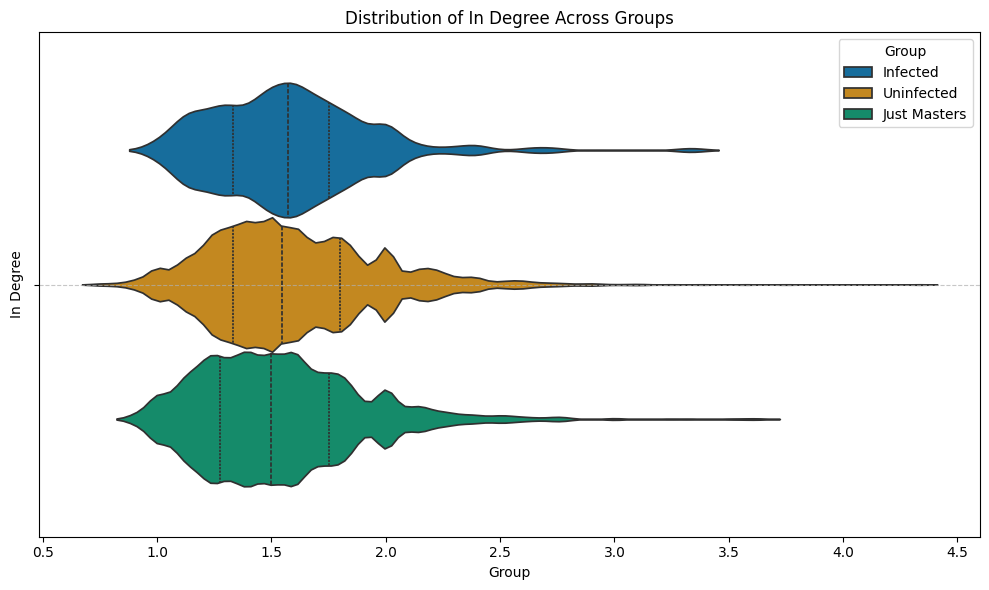

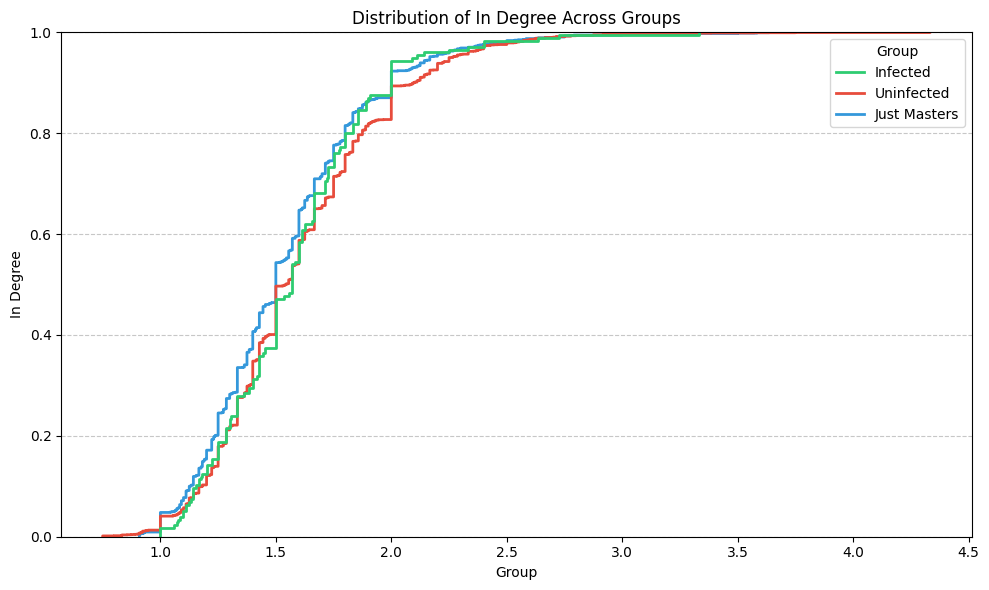

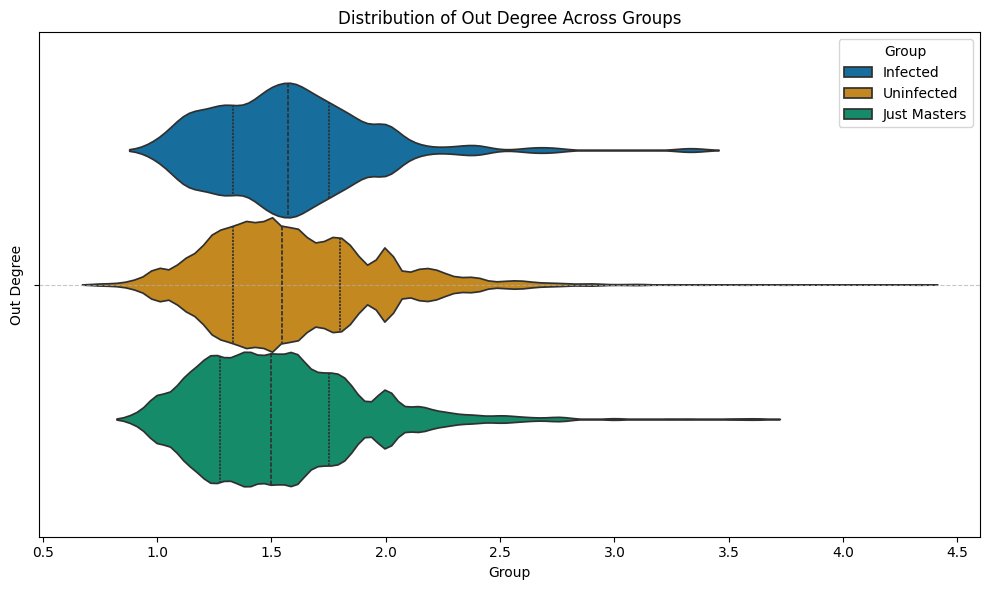

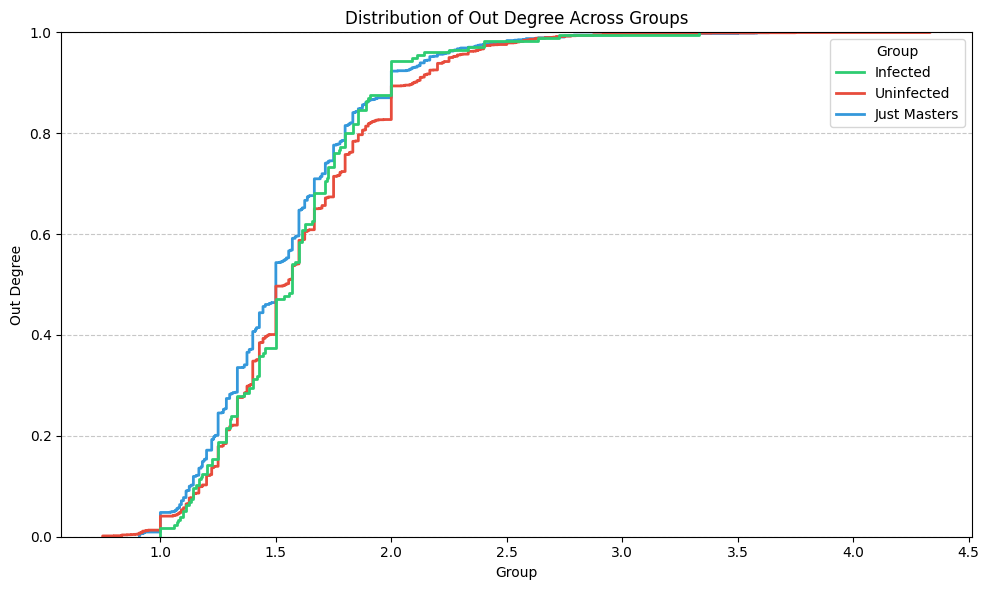

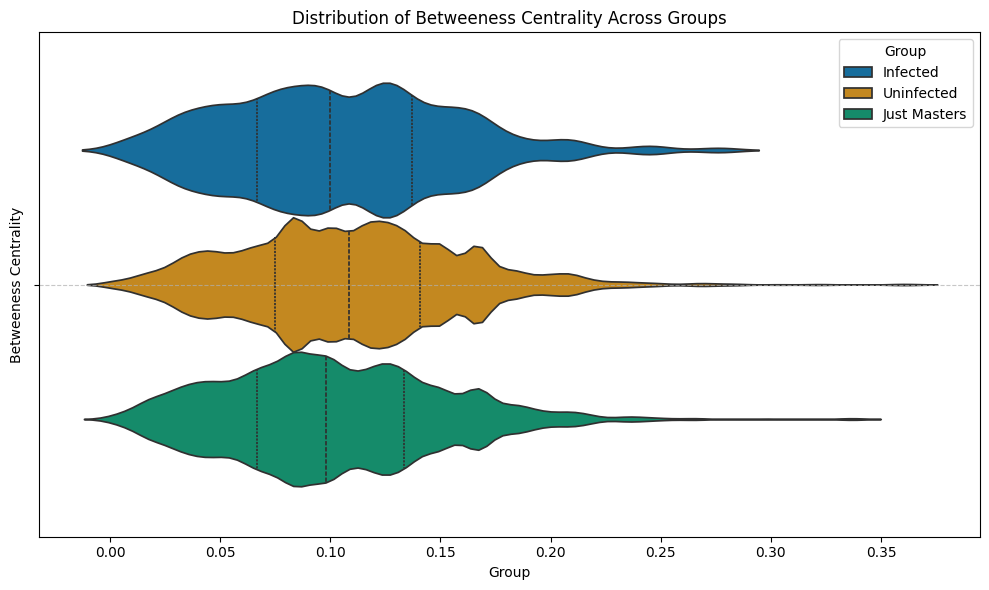

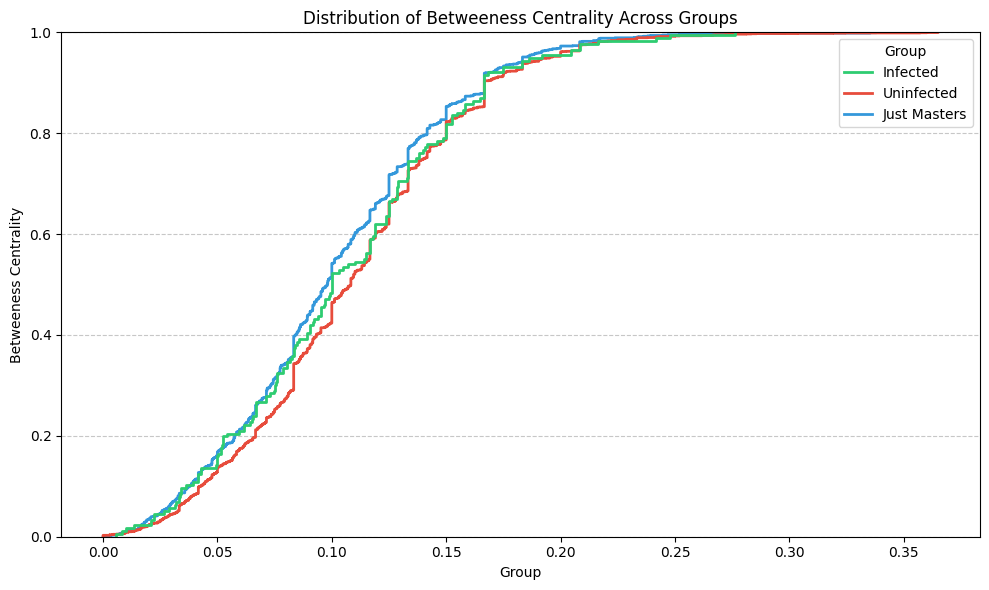

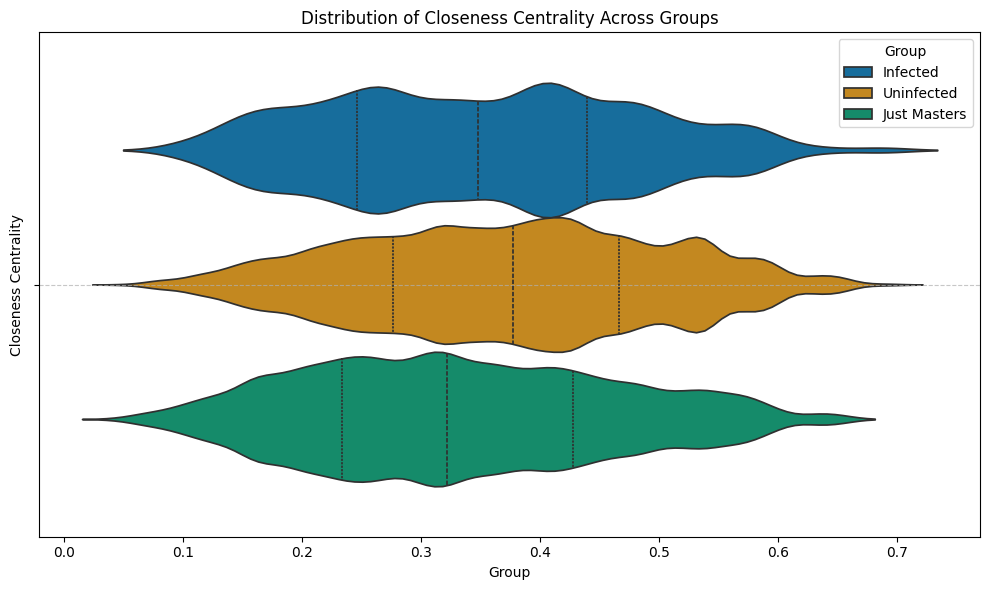

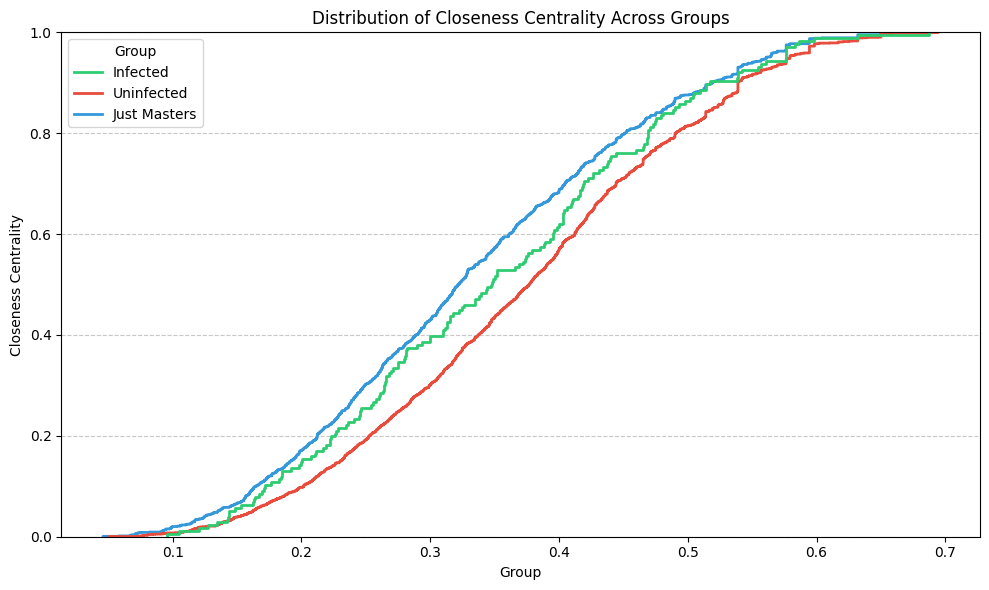

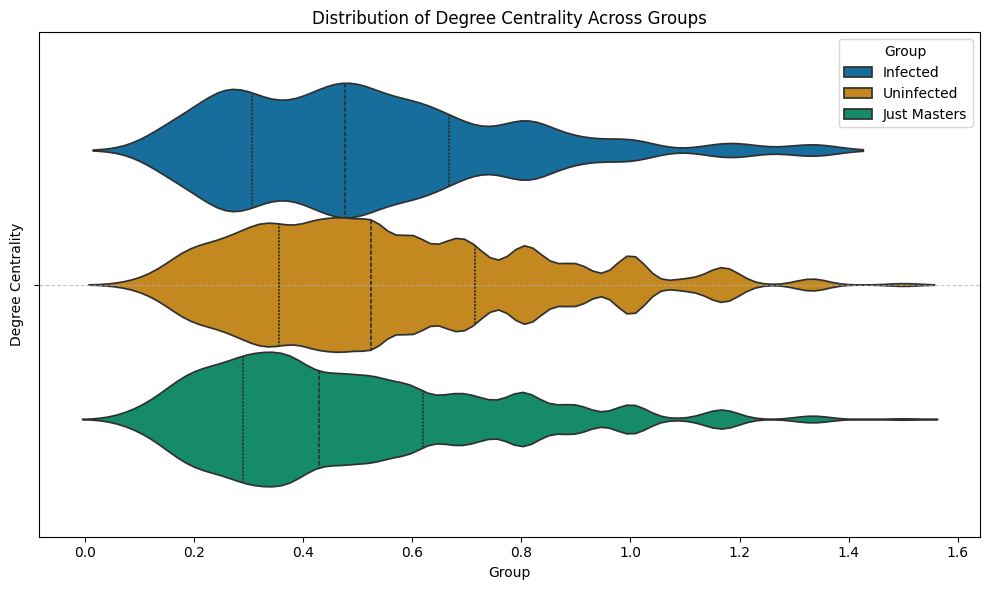

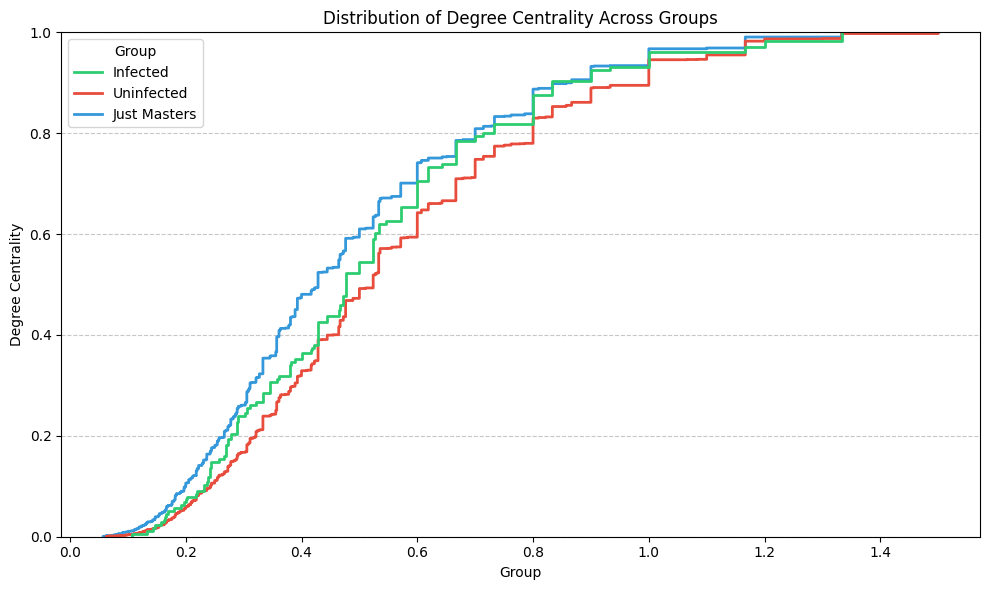

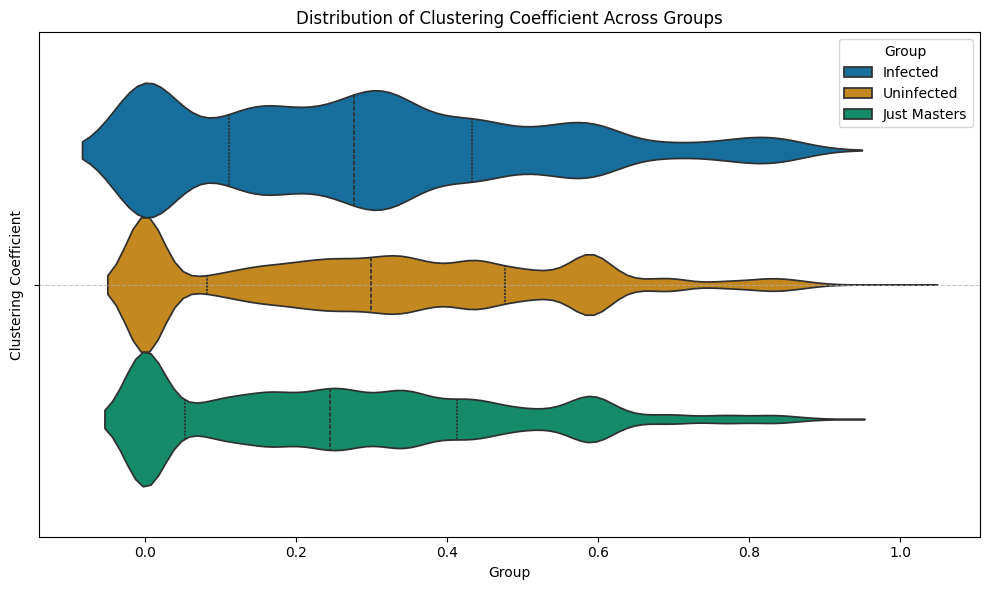

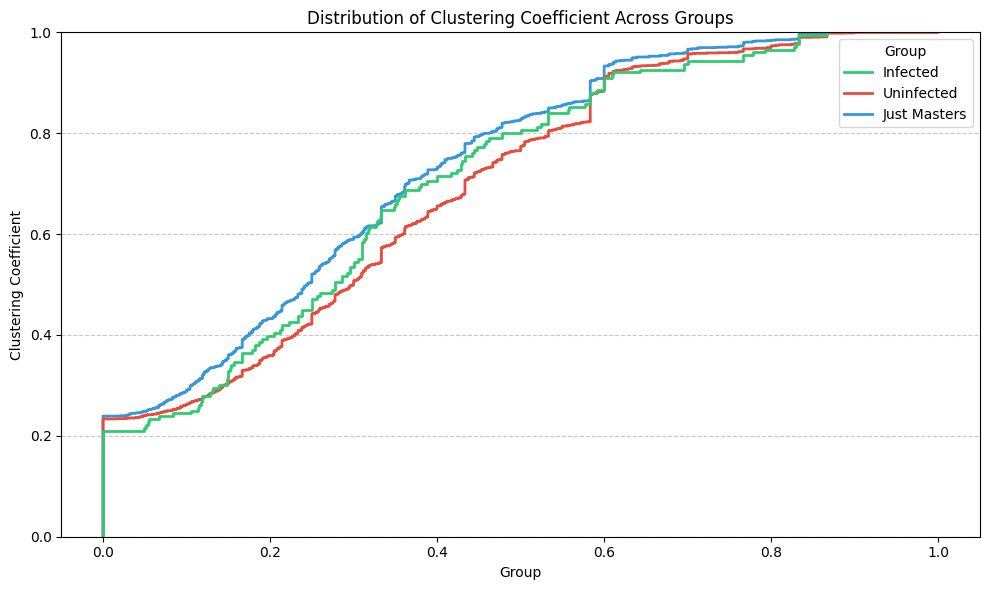

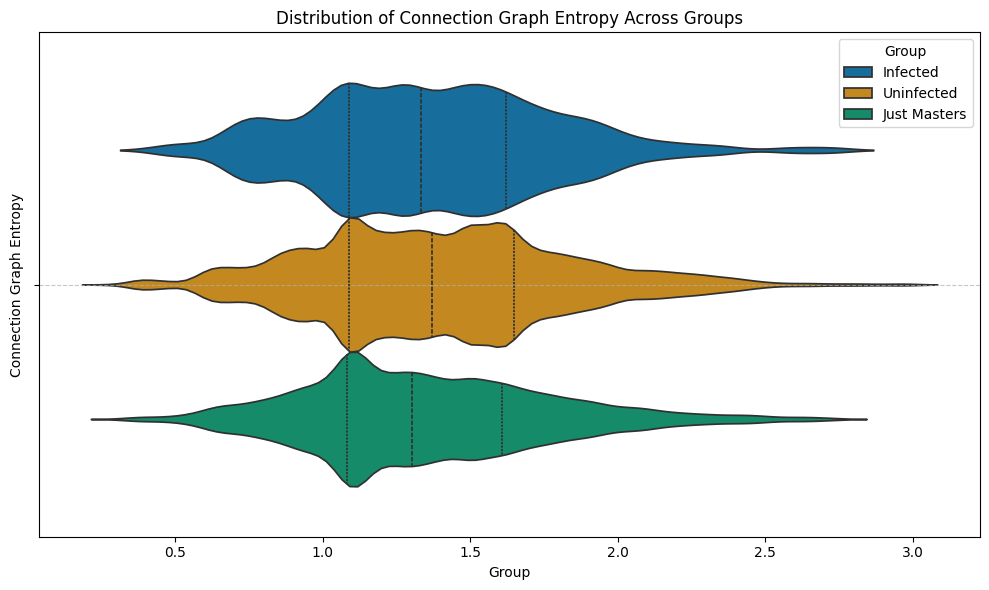

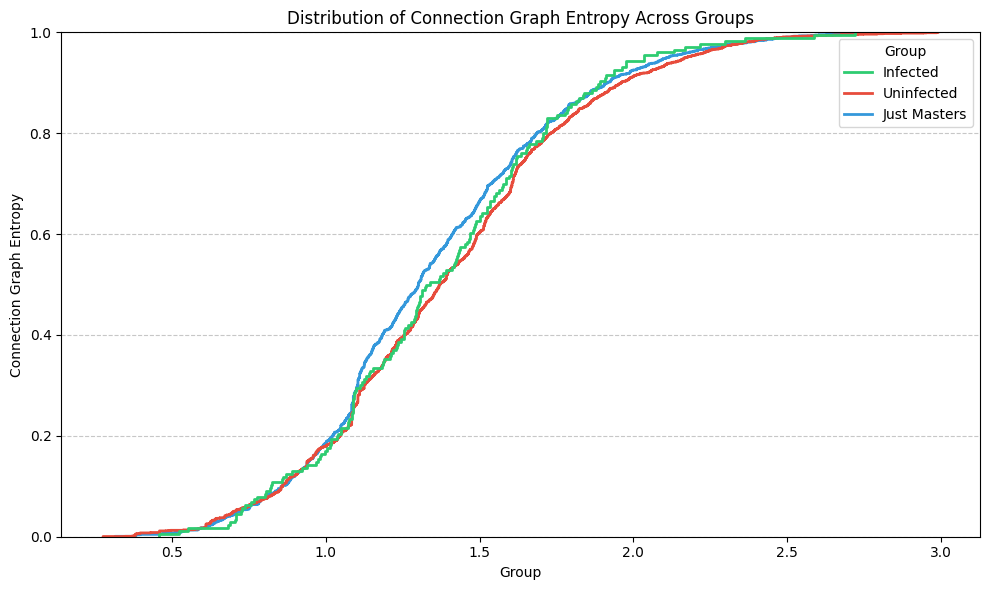

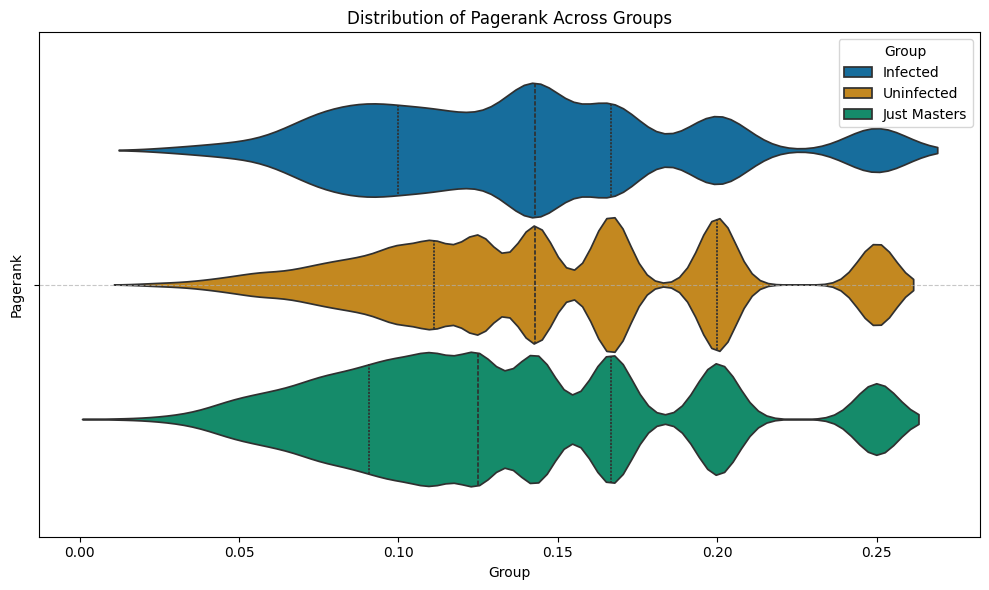

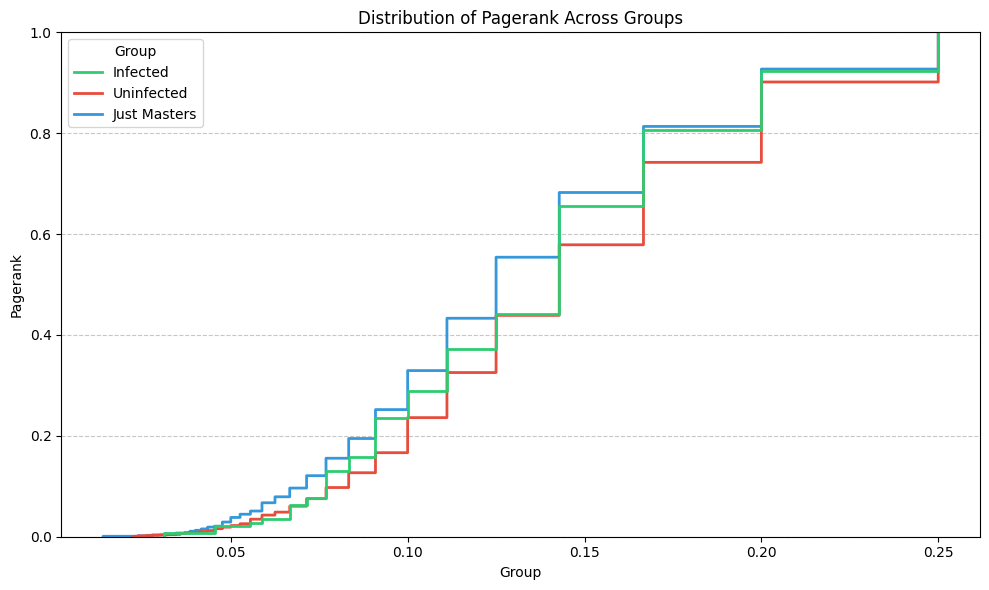

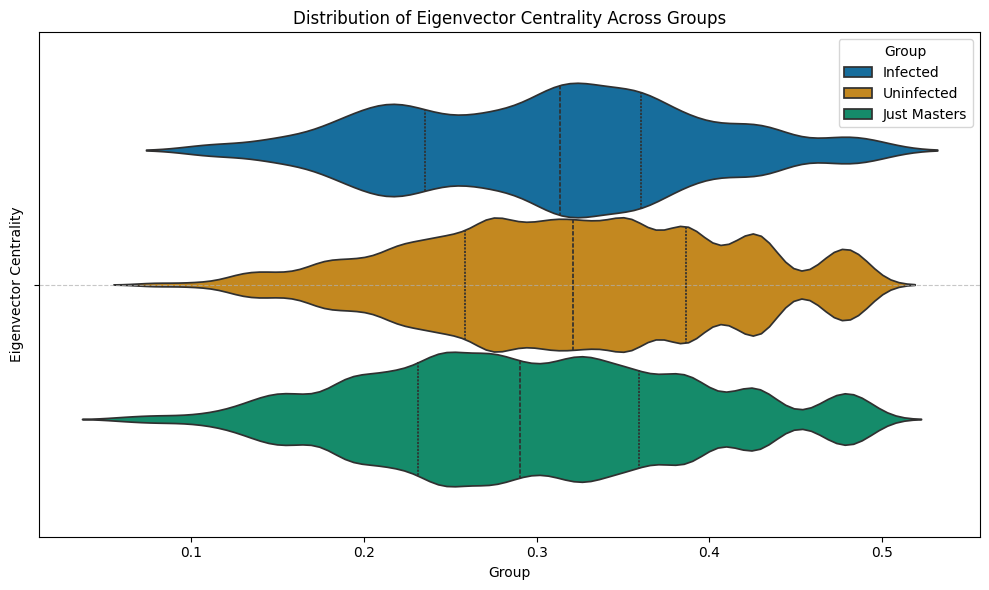

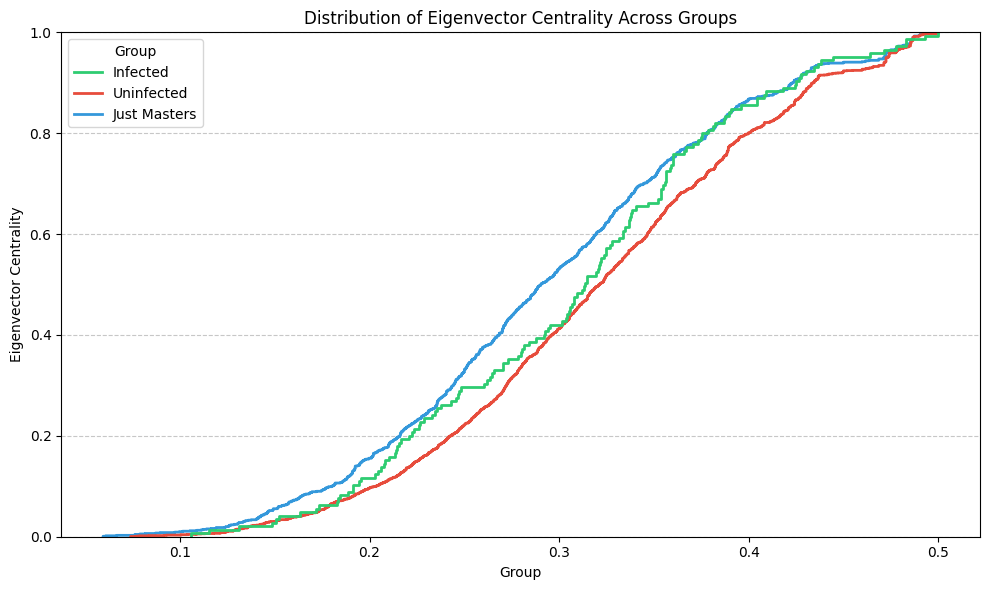

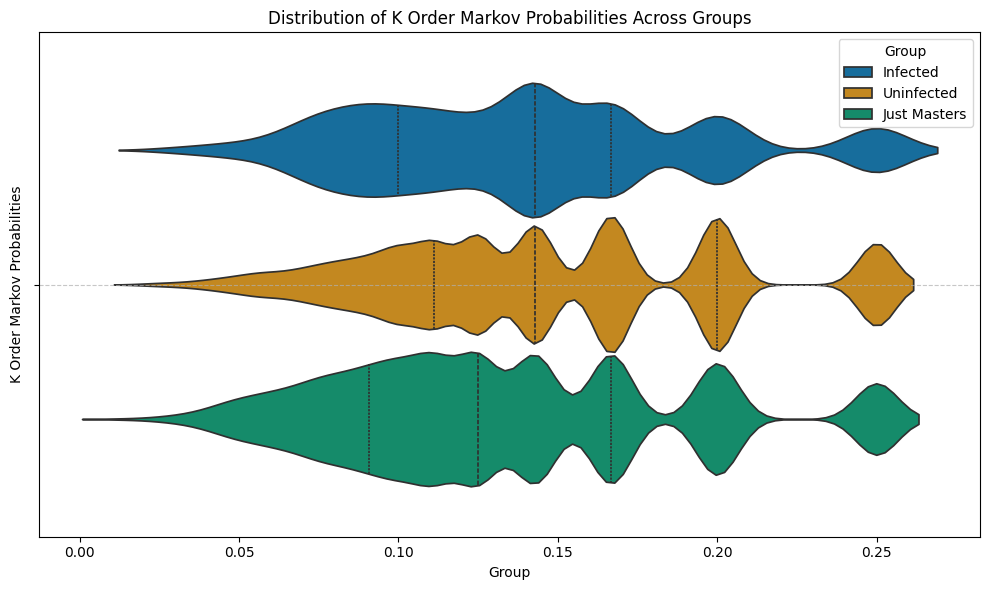

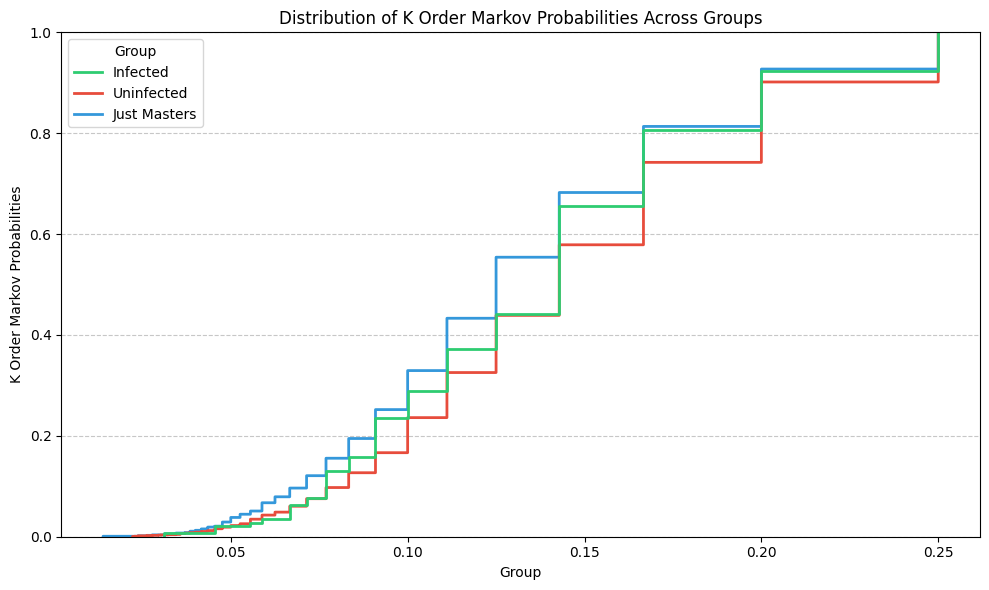

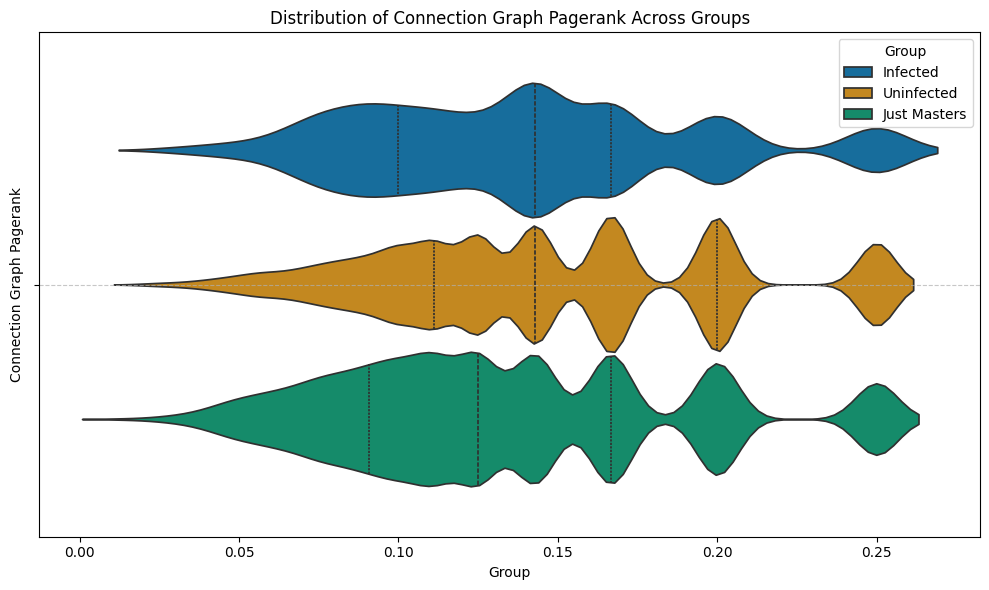

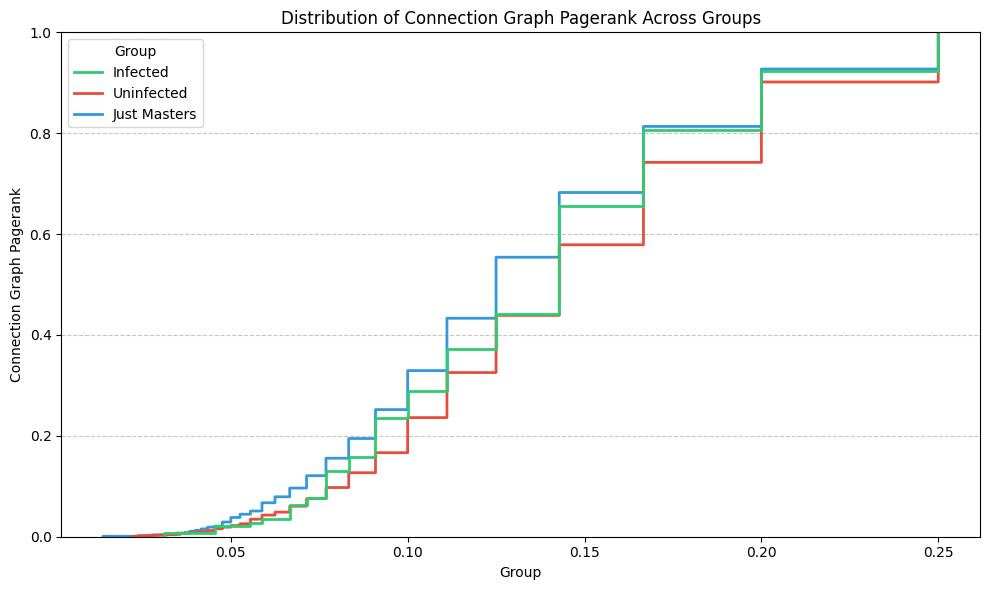

In [ ]:
visualize_distributions_between_groups(has_sockpuppets, uninfected, just_masters)

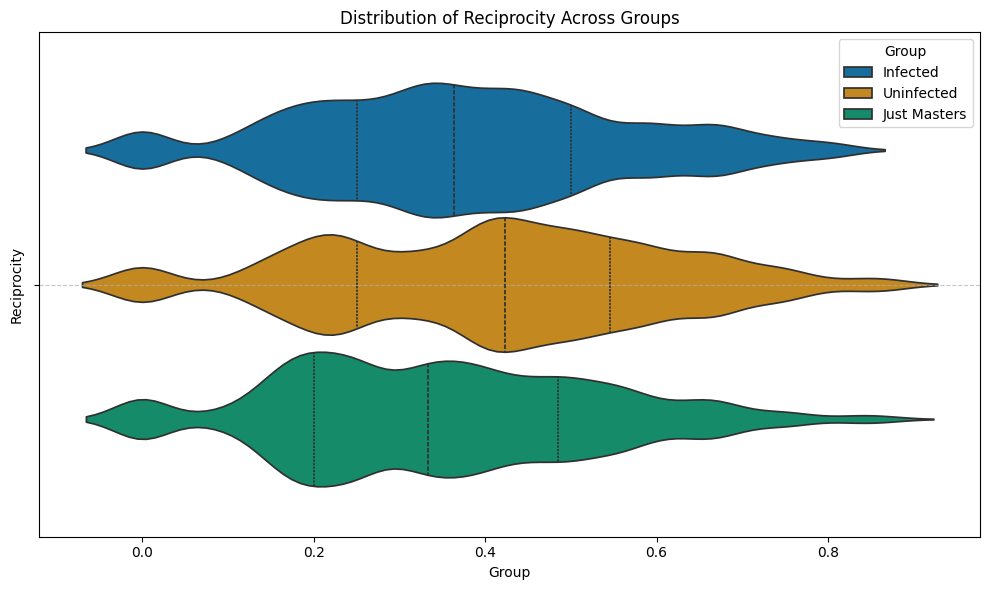

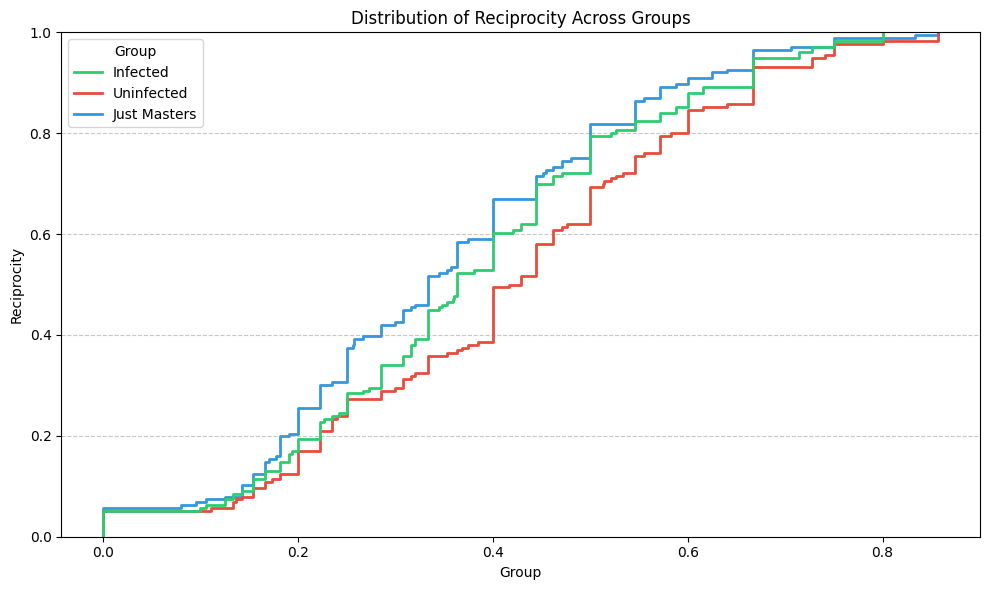

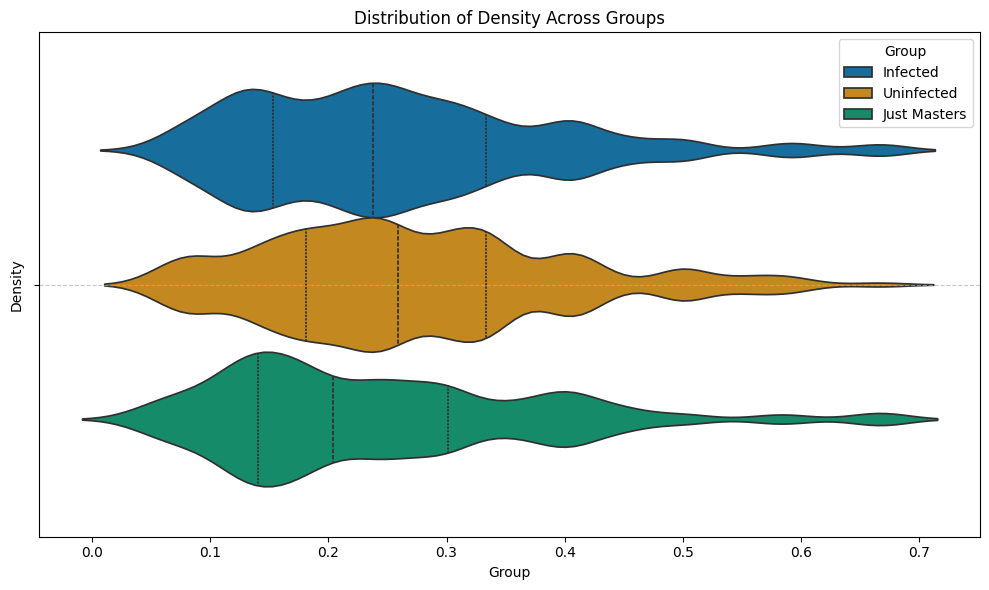

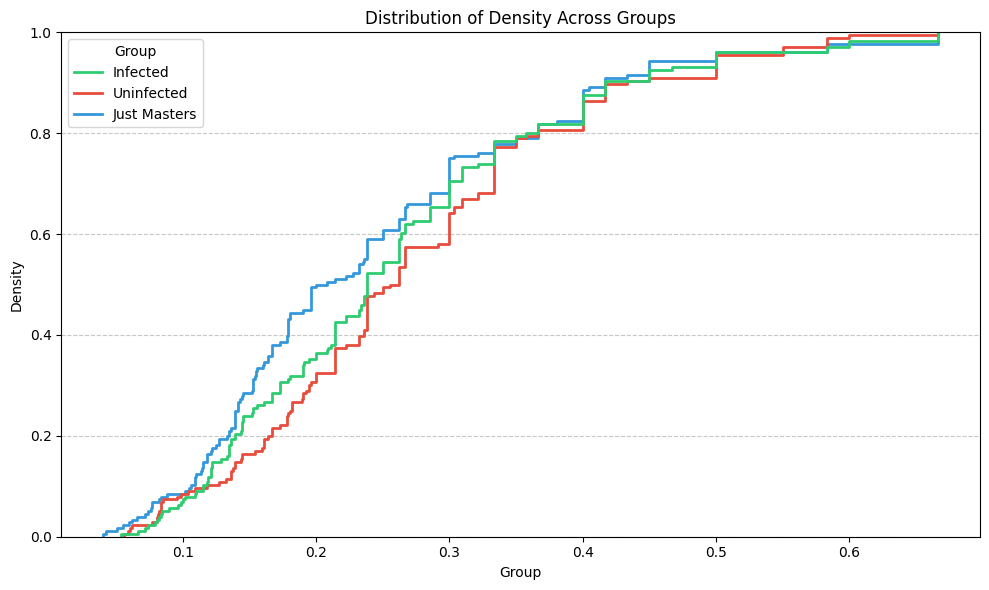

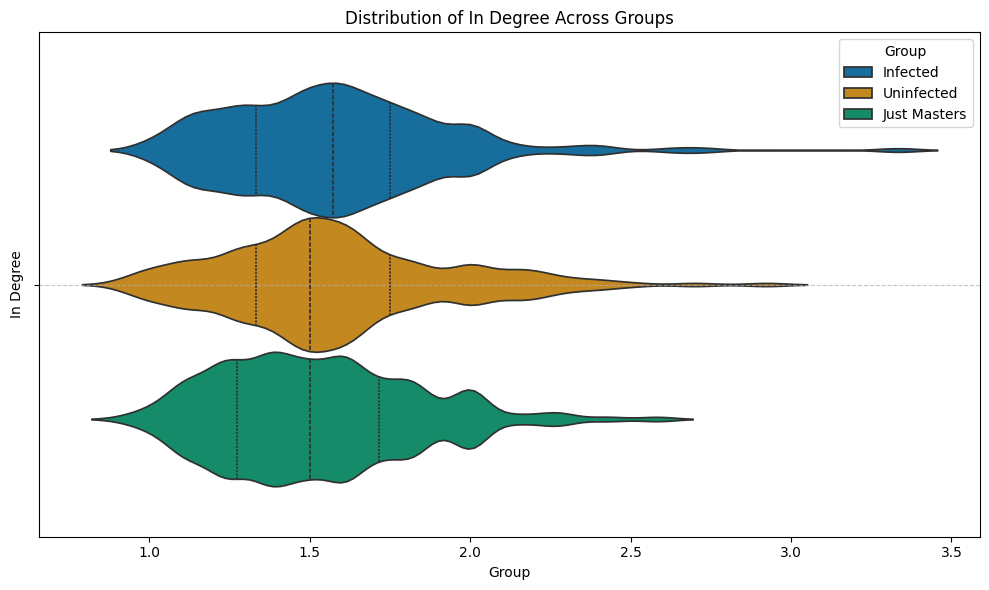

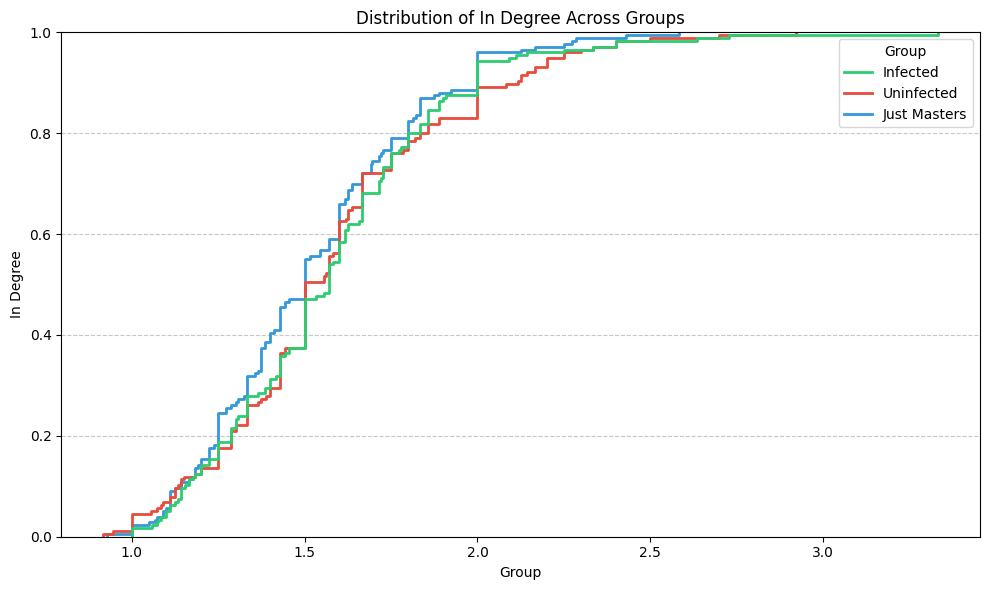

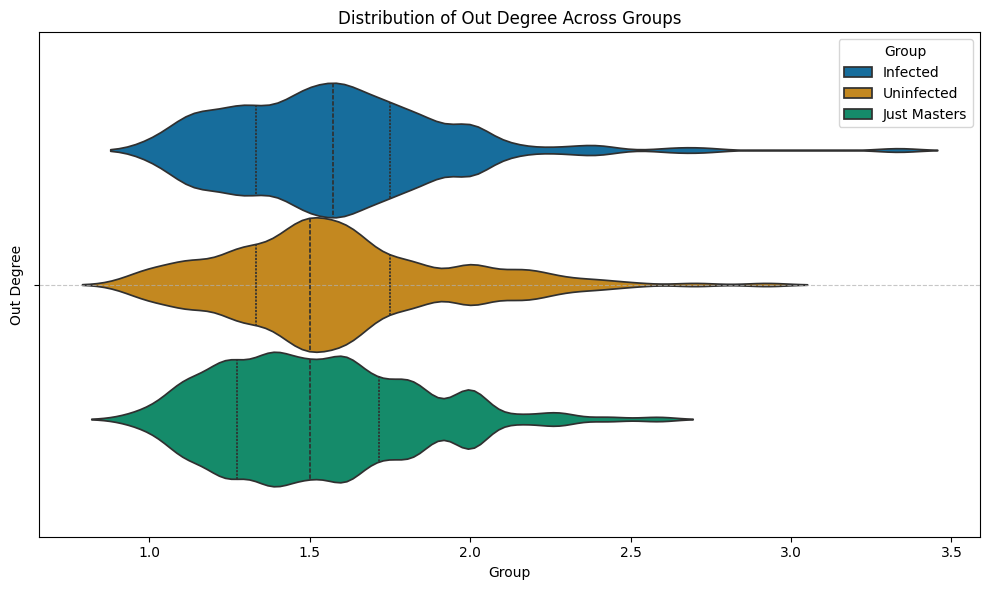

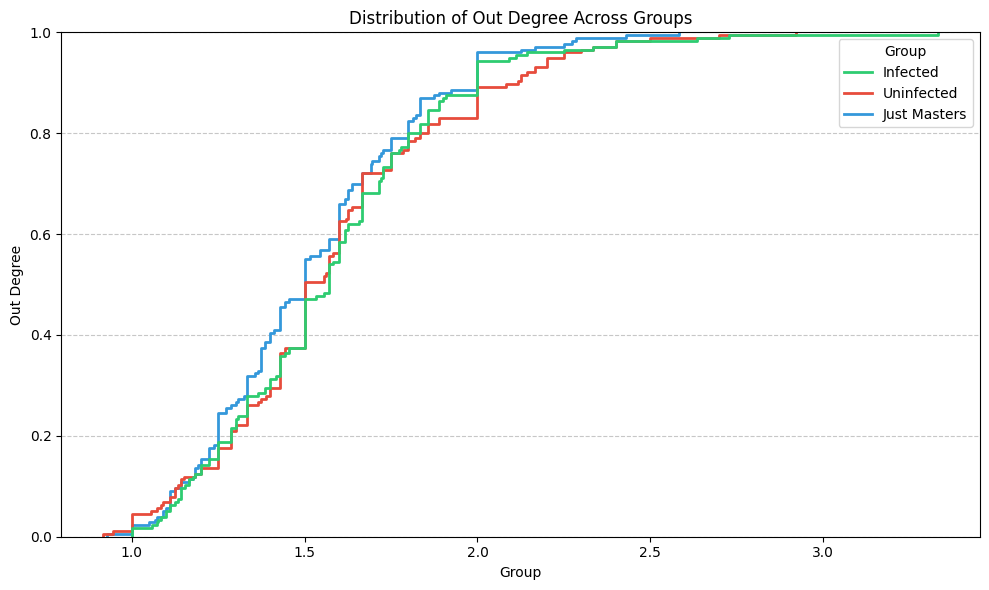

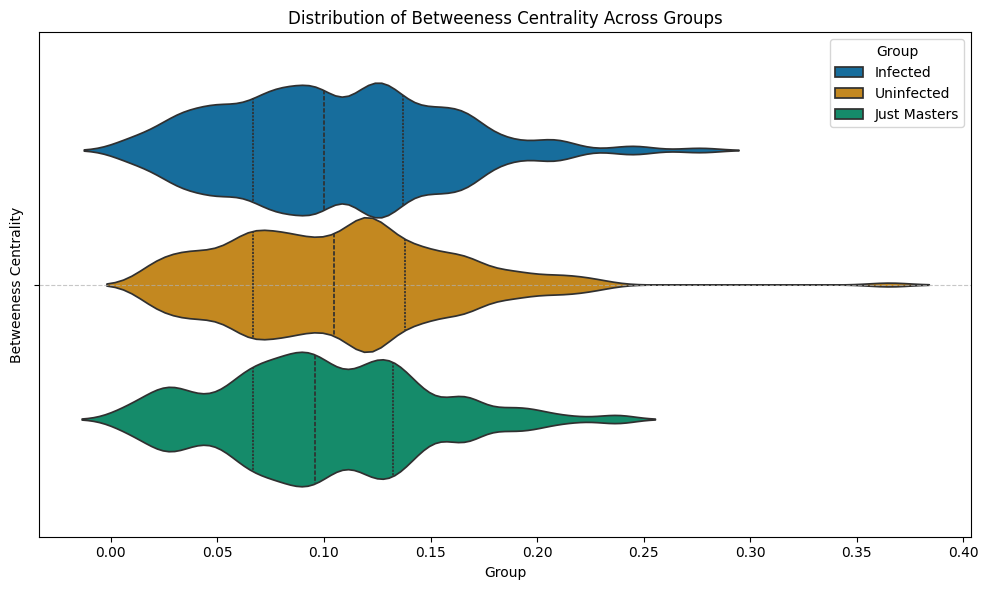

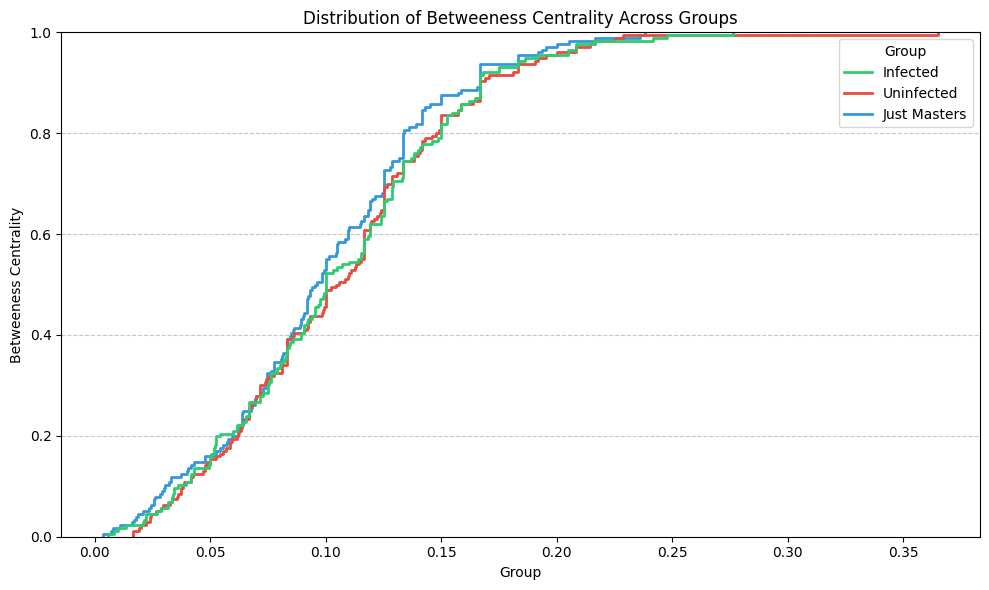

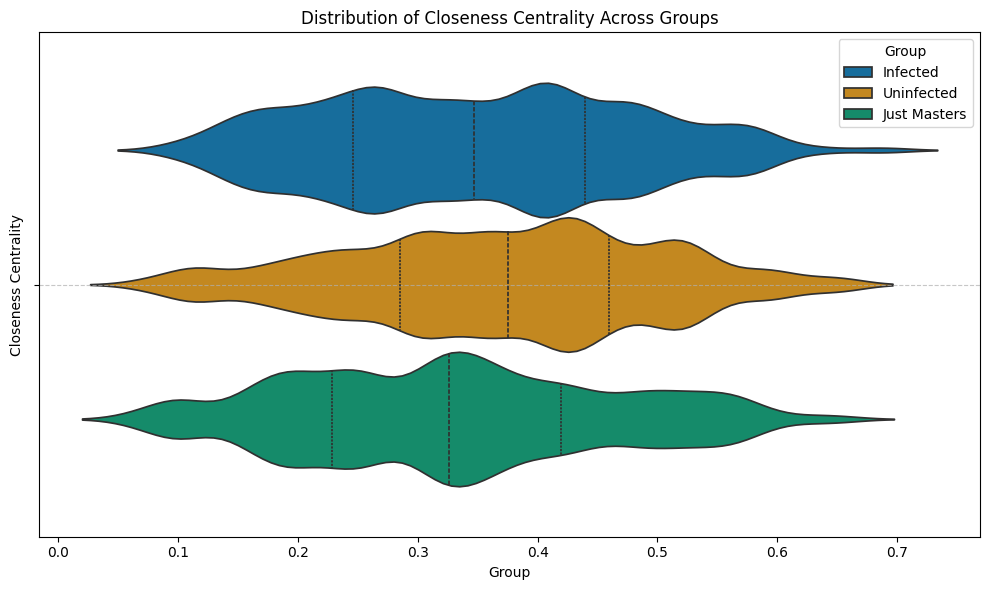

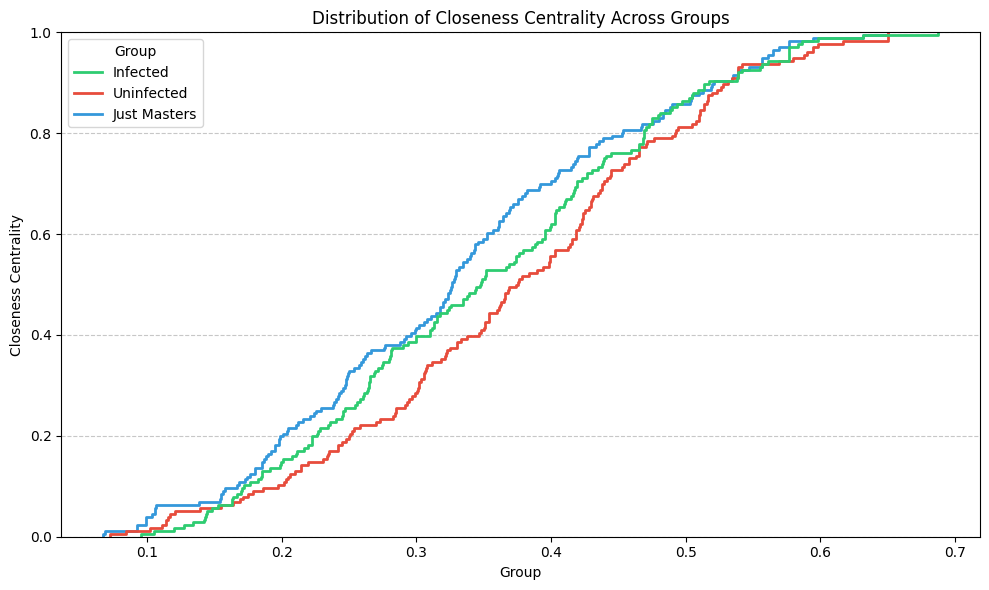

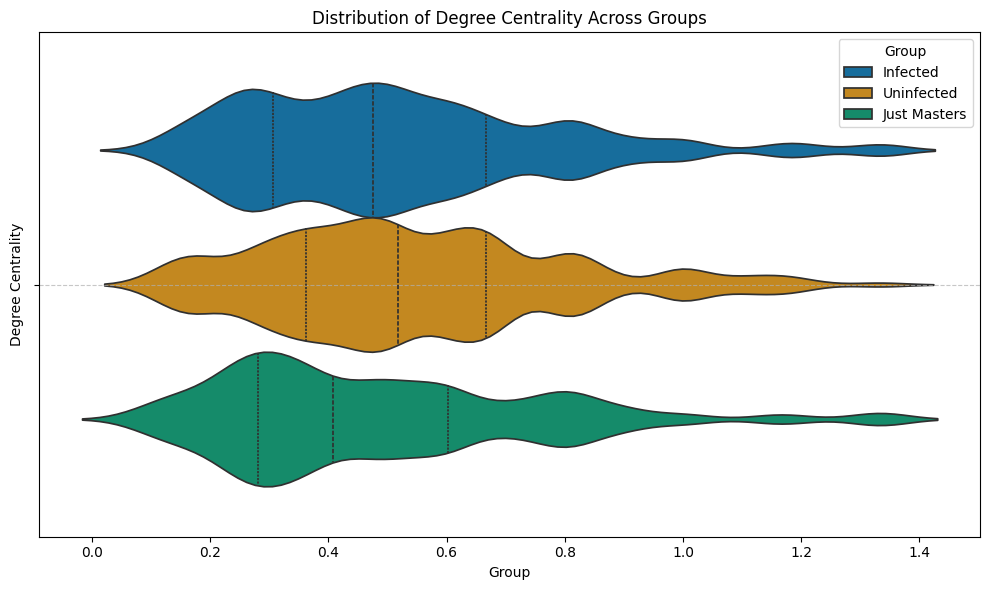

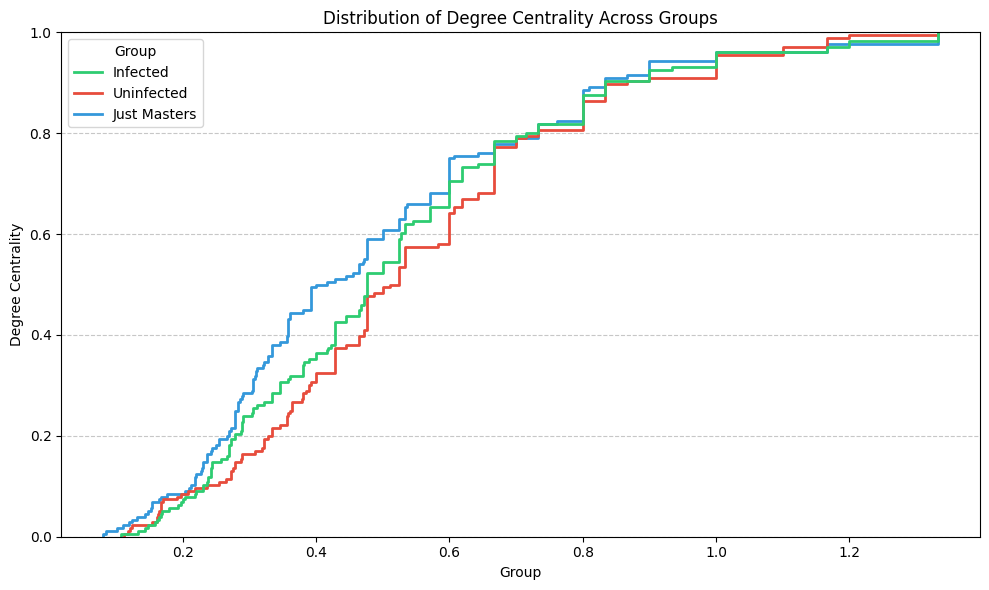

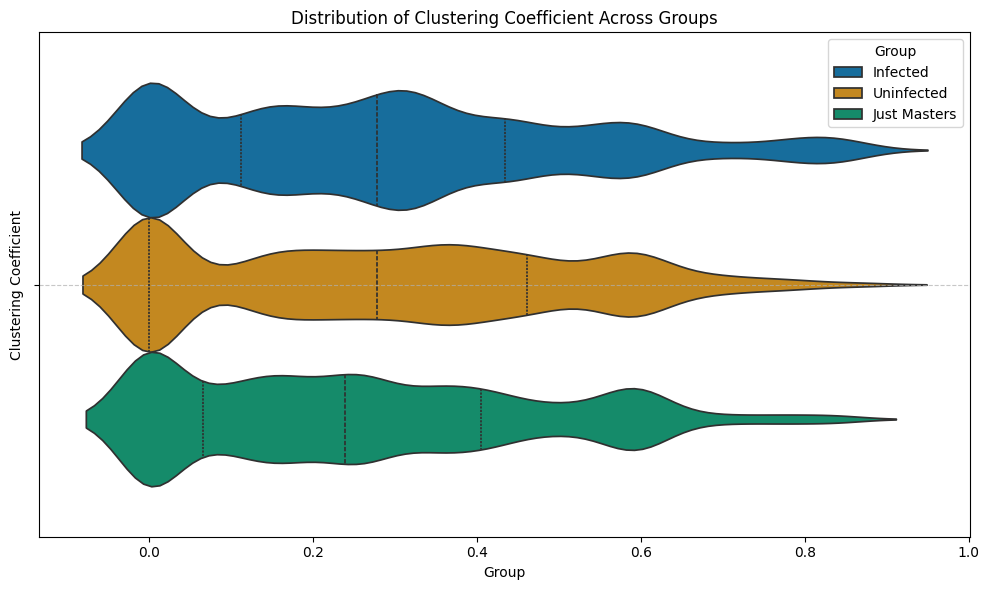

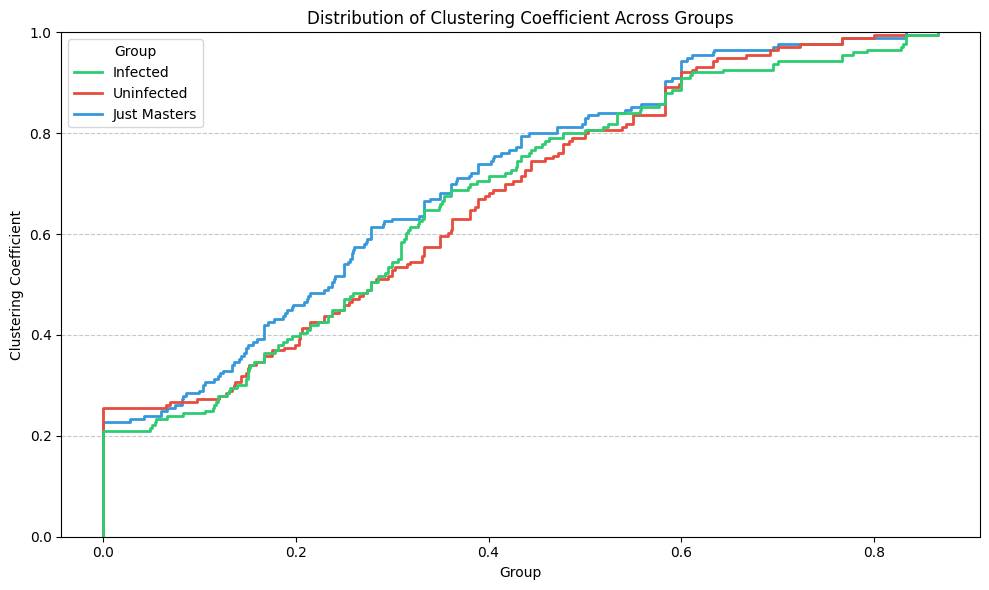

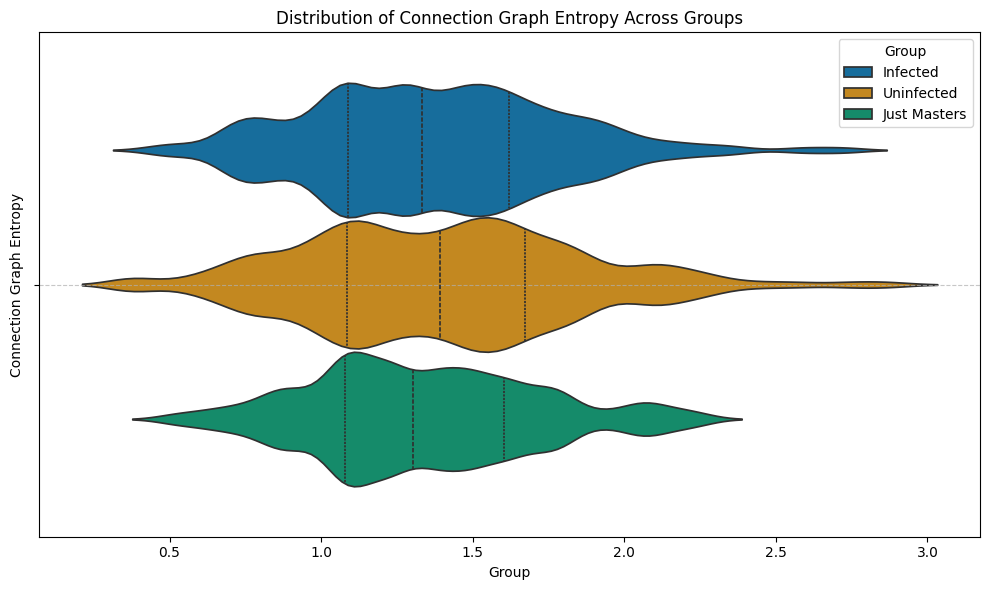

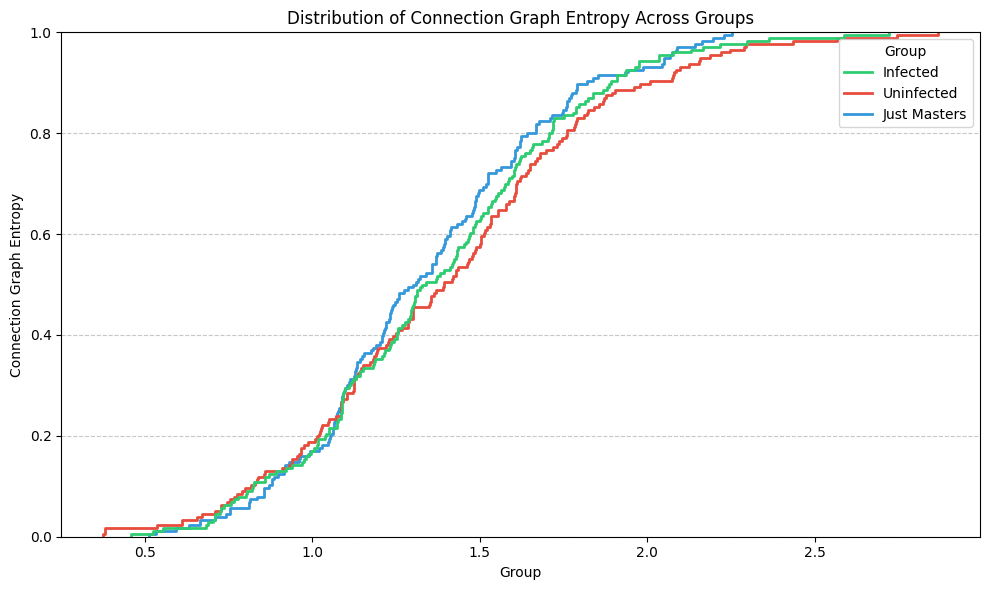

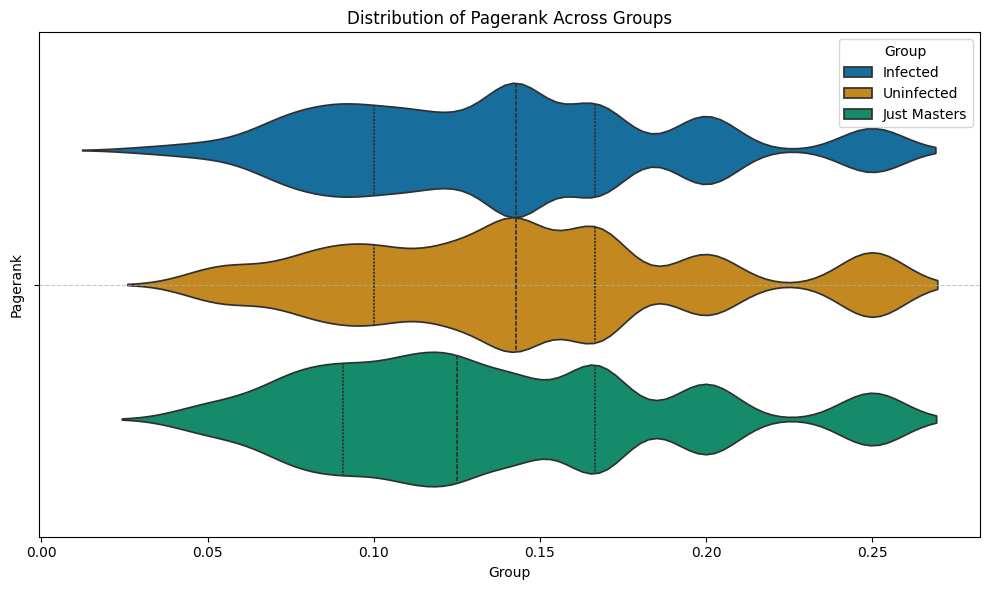

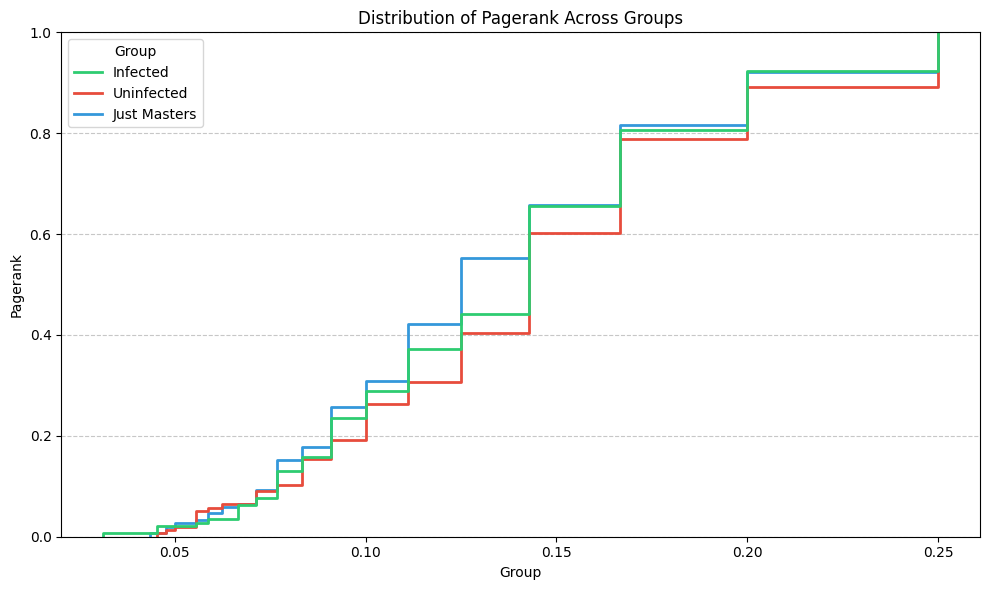

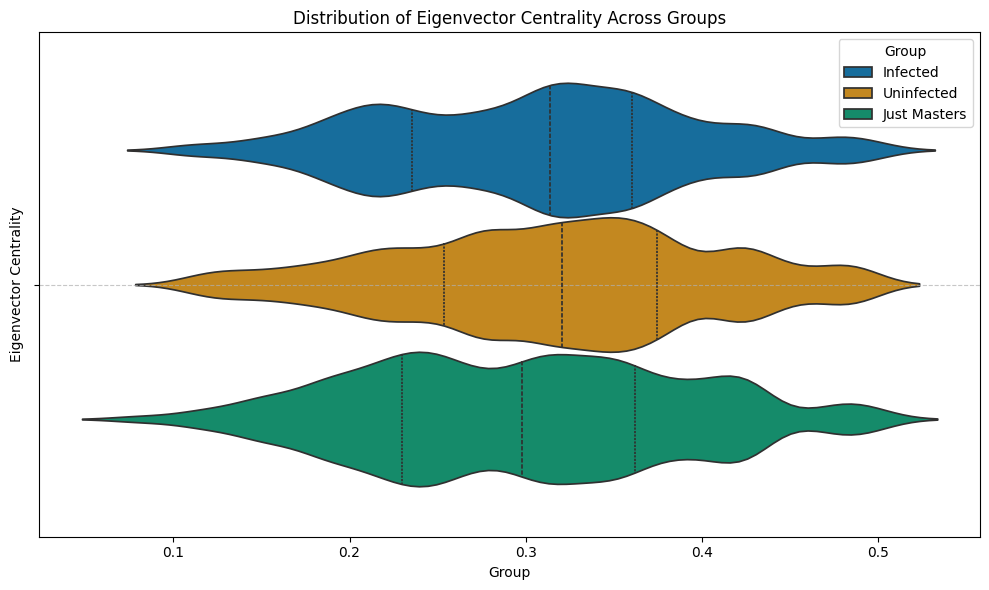

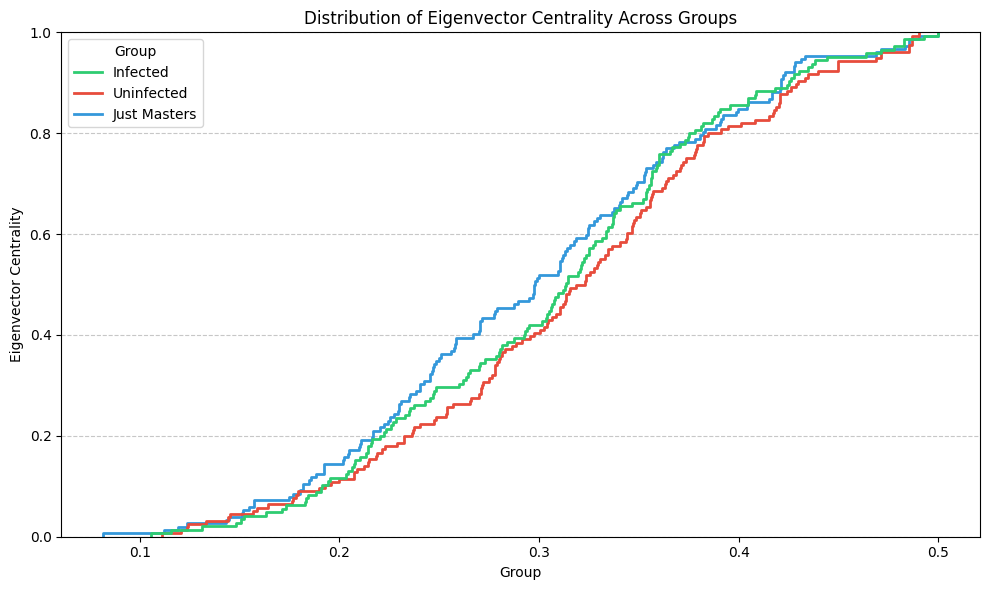

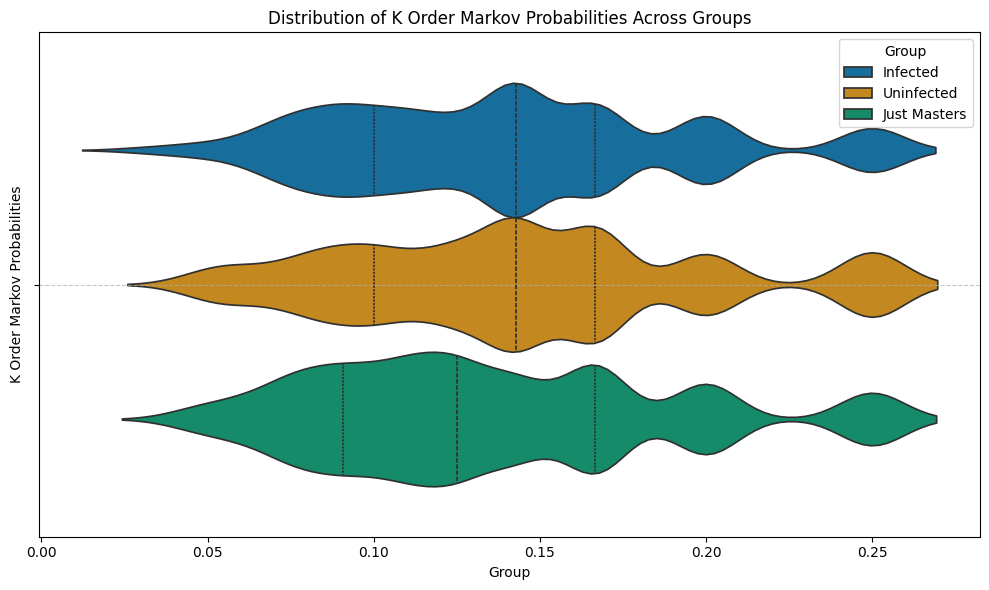

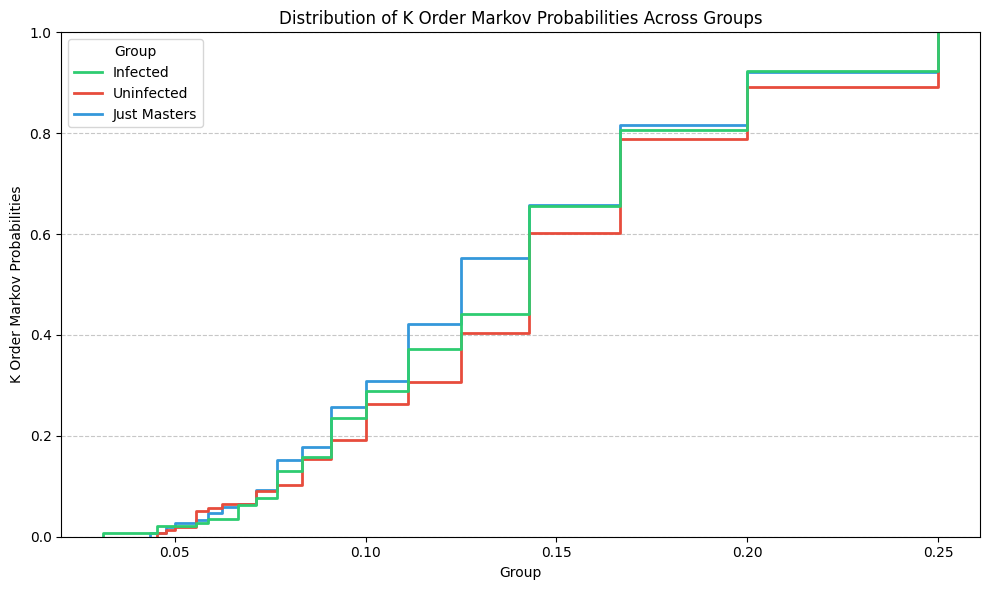

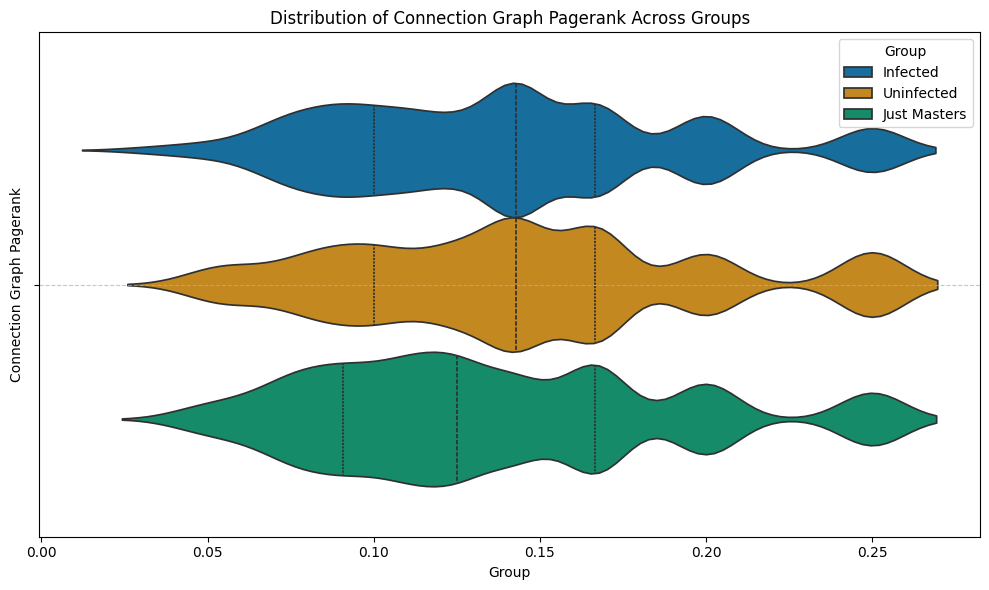

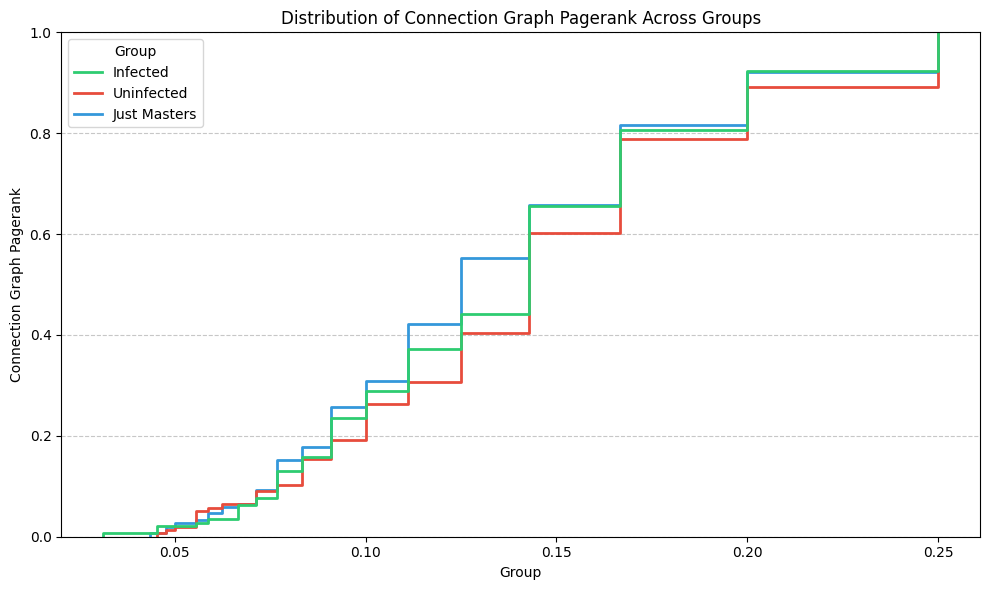

In [ ]:
uninfected_sample = random.sample(uninfected, len(has_sockpuppets))
just_masters_sample = random.sample(just_masters, len(has_sockpuppets))

visualize_distributions_between_groups(has_sockpuppets, uninfected_sample, just_masters_sample)

In [ ]:
# {user: user_metrics}
single_user_metrics = [metric for metric in metrics if metric not in
 ["density", "diameter", "nodes", "edges", "num_puppets", "num_masters", "reciprocity", "connection_graph_density"]]

user_dictionary = {}

for data in dataset:
  for user in data.get("graph", {}).nodes:

    if user not in user_dictionary:
      user_dictionary[user] = {}
      for metric in single_user_metrics:
        user_dictionary[user][metric] = list()

    for metric in single_user_metrics:
      metric_dictionary = data.get("metrics", {}).get(metric, {})
      if metric_dictionary:
        user_dictionary[user][metric].append(metric_dictionary.get(user, None))

num_of_significant_users = 0
for user in user_dictionary:
  if len(user_dictionary[user]["in_degree"]) > 5:
    num_of_significant_users += 1

print(f"Number of significant users: {num_of_significant_users}")

Number of significant users: 653


In [ ]:
for user in user_dictionary:
  for metric in single_user_metrics:
    user_dictionary[user][metric] = [x for x in user_dictionary[user][metric] if x is not None]
    if len(user_dictionary[user][metric]) != 0:
      user_dictionary[user][metric] = np.mean(user_dictionary[user][metric])

user_dictionary = {user: user_dictionary[user] for user in user_dictionary if not isinstance(user_dictionary[user]["pagerank"], list)}

sockpuppet_user_metrics = {user: user_dictionary[user] for user in user_dictionary if classify_user(user)[0] == "Puppet"}
master_user_metrics = {user: user_dictionary[user] for user in user_dictionary if classify_user(user)[0] == "Puppet Master"}
regular_user_metrics = {user: user_dictionary[user] for user in user_dictionary if classify_user(user)[0] == "User" and user != "Root"}

print("\n--- Sockpuppet User Metrics ---")
for i, (user, metric_dict) in enumerate(sockpuppet_user_metrics.items()):
  print(f"User: {user}, Metrics: {metric_dict}")
  if i >= 10:
    break

print("\n--- Master Metrics ---")
for i, (user, metric_dict) in enumerate(master_user_metrics.items()):
  print(f"User: {user}, Metrics: {metric_dict}")
  if i >= 10:
    break

print("\n--- Regular User Metrics ---")
for i, (user, metric_dict) in enumerate(regular_user_metrics.items()):
  print(f"User: {user}, Metrics: {metric_dict}")
  if i >= 10:
    break


--- Sockpuppet User Metrics ---
User: Dangling Reference, Metrics: {'in_degree': np.float64(1.7454545454545454), 'out_degree': np.float64(2.1454545454545455), 'betweeness_centrality': np.float64(0.17030056333884086), 'closeness_centrality': np.float64(0.37458481791588005), 'degree_centrality': np.float64(0.703491859018175), 'clustering_coefficient': np.float64(0.30121212121212115), 'connection_graph_entropy': np.float64(1.4452679774467267), 'pagerank': np.float64(0.17395025869297778), 'eigenvector_centrality': np.float64(0.35675160591918803), 'k order markov probabilities': np.float64(0.1791029241105471), 'connection_graph_pagerank': np.float64(0.15041703771018475)}
User: Esfera Explosiva, Metrics: {'in_degree': np.float64(1.4), 'out_degree': np.float64(2.4), 'betweeness_centrality': np.float64(0.14966699966699964), 'closeness_centrality': np.float64(0.23558718224131758), 'degree_centrality': np.float64(0.4821428571428571), 'clustering_coefficient': np.float64(0.5066666666666666), 'co

In [ ]:
results_sockpuppets = {}
results_users = {}
results_masters = {}

comparison_sockpuppets_users = {}
comparison_sockpuppets_masters = {}
comparison_masters_users = {}

for metric in single_user_metrics:
  # Extract values for infected graphs
  sockpuppet_values = extract_metric_values(sockpuppet_user_metrics, metric, data_group_for_graphs=False)
  results_sockpuppets[metric] = calculate_descriptive_statistics(sockpuppet_values)

  # Extract values for uninfected graphs
  users_values = extract_metric_values(regular_user_metrics, metric, data_group_for_graphs=False)
  results_users[metric] = calculate_descriptive_statistics(users_values)

  # Extract values for master-only graphs
  masters_values = extract_metric_values(master_user_metrics, metric, data_group_for_graphs=False)
  results_masters[metric] = calculate_descriptive_statistics(masters_values)

  compared_puppets_regular_users = run_statistics_between_two_groups(sockpuppet_user_metrics, regular_user_metrics, metric, data_group_for_graphs=False)
  compared_puppets_masters = run_statistics_between_two_groups(sockpuppet_user_metrics, master_user_metrics, metric, data_group_for_graphs=False)
  compared_masters_regular_users = run_statistics_between_two_groups(master_user_metrics, regular_user_metrics, metric, data_group_for_graphs=False)

  comparison_sockpuppets_users[metric] = compared_puppets_regular_users
  comparison_sockpuppets_masters[metric] = compared_puppets_masters
  comparison_masters_users[metric] = compared_masters_regular_users

In [ ]:
print("\n--- Descriptive Statistics for Sockpuppets ---")
for metric, stats in results_sockpuppets.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in stats.items():
        print(f"{stat_name}: {stat_value}")

print("\n--- Descriptive Statistics for Regular Users ---")
for metric, stats in results_users.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in stats.items():
        print(f"{stat_name}: {stat_value}")

print("\n--- Descriptive Statistics for Masters ---")
for metric, stats in results_masters.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in stats.items():
        print(f"{stat_name}: {stat_value}")


--- Descriptive Statistics for Sockpuppets ---

Metric: in_degree
Mean: 1.44251341991342
Std Dev: 0.8266841489472565
Median: 1.3333333333333333
IQR: 0.8571428571428572

Metric: out_degree
Mean: 1.7137038961038962
Std Dev: 0.872248828697728
Median: 1.44
IQR: 1.2857142857142856

Metric: betweeness_centrality
Mean: 0.1261263651939955
Std Dev: 0.11492328672855363
Median: 0.09143054059230529
IQR: 0.18426870748299318

Metric: closeness_centrality
Mean: 0.28216169258831647
Std Dev: 0.15179507331901157
Median: 0.24168552036199095
IQR: 0.20542095980692476

Metric: degree_centrality
Mean: 0.5013286167472162
Std Dev: 0.38472824418479534
Median: 0.375
IQR: 0.5181405895691609

Metric: clustering_coefficient
Mean: 0.2191957864357864
Std Dev: 0.21247461789993843
Median: 0.16666666666666666
IQR: 0.3333333333333333

Metric: connection_graph_entropy
Mean: 1.1085138041443234
Std Dev: 0.5890271575583775
Median: 1.0854569912799772
IQR: 0.5269721433922372

Metric: pagerank
Mean: 0.1260193668150196
Std Dev:

In [ ]:
print("\n--- Statistical Comparisons: Sockpuppets vs. Regular Users ---")
for metric, comparison_stats in comparison_sockpuppets_users.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in comparison_stats.items():
        print(f"  {stat_name}: {stat_value}")

print("\n--- Statistical Comparisons: Sockpuppets vs. Masters ---")
for metric, comparison_stats in comparison_sockpuppets_masters.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in comparison_stats.items():
        print(f"  {stat_name}: {stat_value}")

print("\n--- Statistical Comparisons: Masters vs. Regular Users ---")
for metric, comparison_stats in comparison_masters_users.items():
    print(f"\nMetric: {metric}")
    for stat_name, stat_value in comparison_stats.items():
        print(f"  {stat_name}: {stat_value}")


--- Statistical Comparisons: Sockpuppets vs. Regular Users ---

Metric: in_degree
  U-Stat: 38398.0
  P-Value: 0.4569291050614557
  Cohen's D: 0.07845031777555826

Metric: out_degree
  U-Stat: 36989.0
  P-Value: 0.6822863708886735
  Cohen's D: 0.037541496786779184

Metric: betweeness_centrality
  U-Stat: 42543.0
  P-Value: 0.07776443047701394
  Cohen's D: 0.24069354240276367

Metric: closeness_centrality
  U-Stat: 37077.5
  P-Value: 0.6798672967902638
  Cohen's D: 0.08827449714165847

Metric: degree_centrality
  U-Stat: 39119.0
  P-Value: 0.36335595128125453
  Cohen's D: 0.18695167234356735

Metric: clustering_coefficient
  U-Stat: 37653.5
  P-Value: 0.5666774626963942
  Cohen's D: -0.039922991123298696

Metric: connection_graph_entropy
  U-Stat: 32510.5
  P-Value: 0.48138106985780327
  Cohen's D: -0.1332097955104975

Metric: pagerank
  U-Stat: 37938.0
  P-Value: 0.534463977276493
  Cohen's D: 0.19242890148151912

Metric: eigenvector_centrality
  U-Stat: 36783.0
  P-Value: 0.733979792

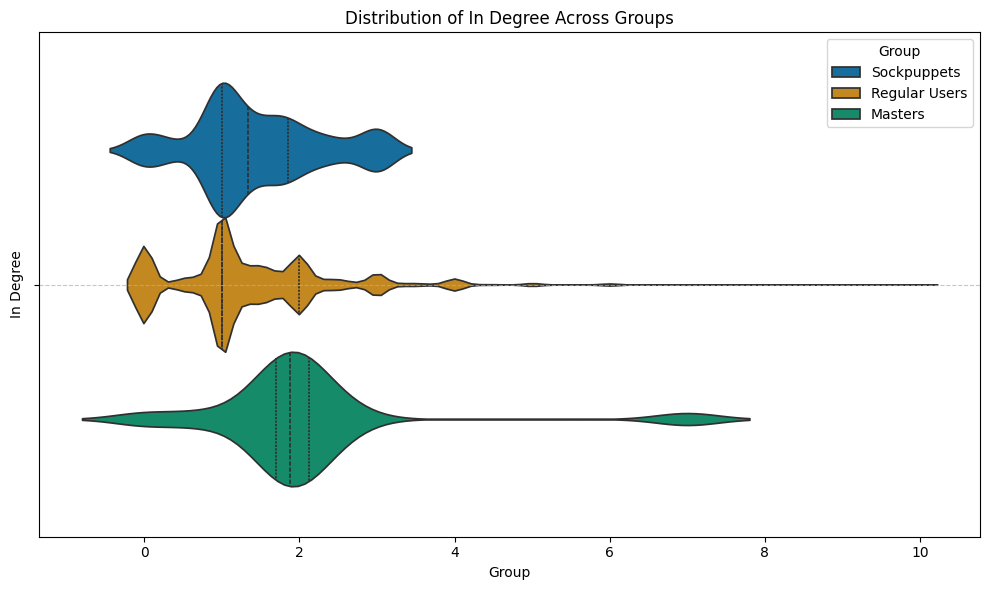

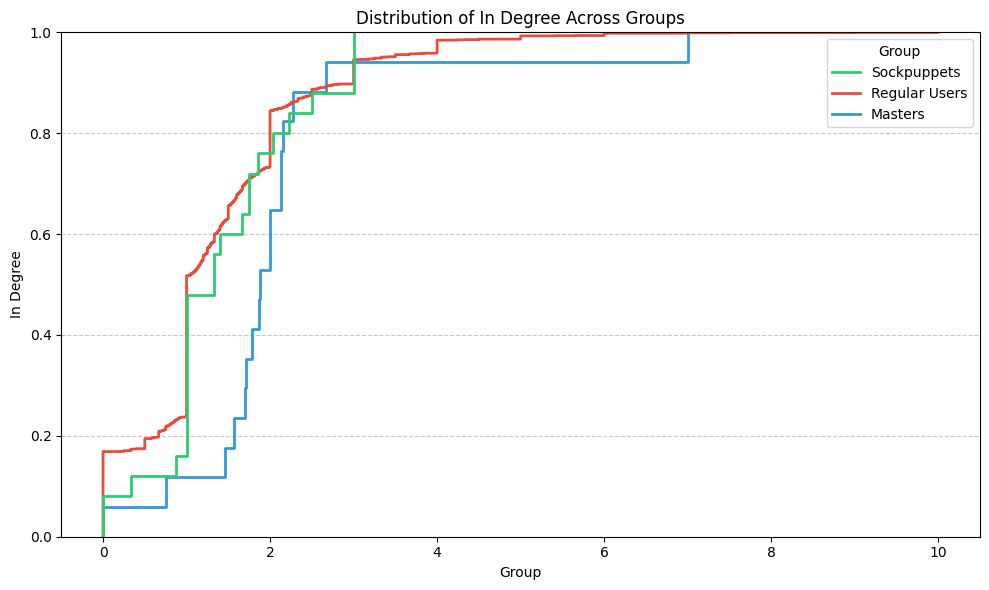

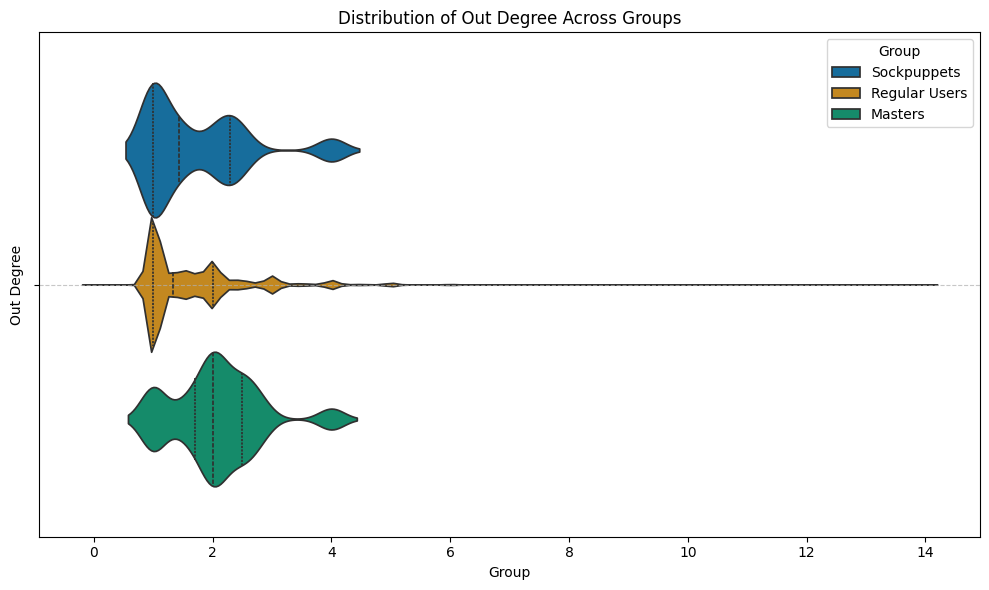

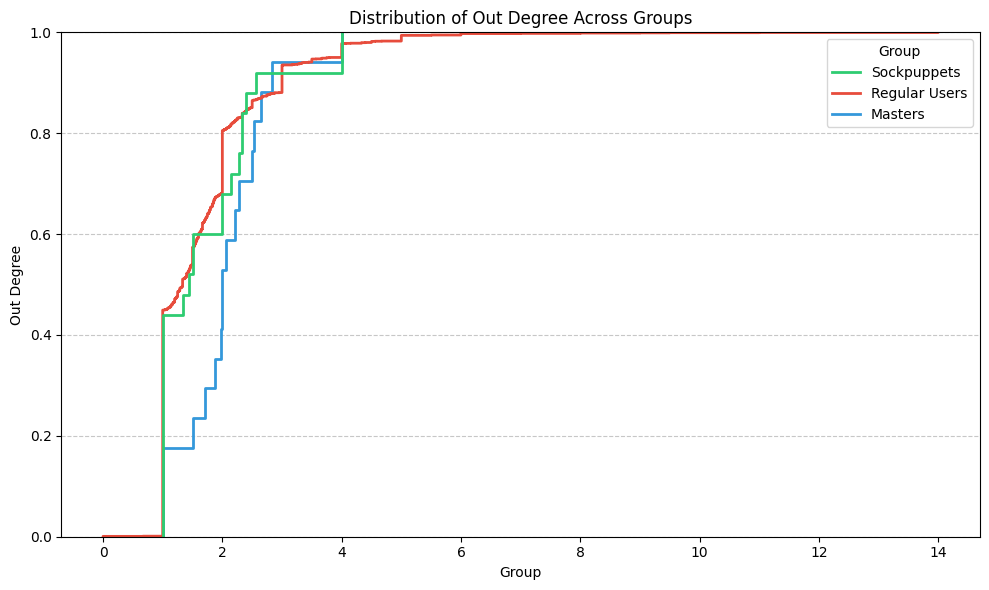

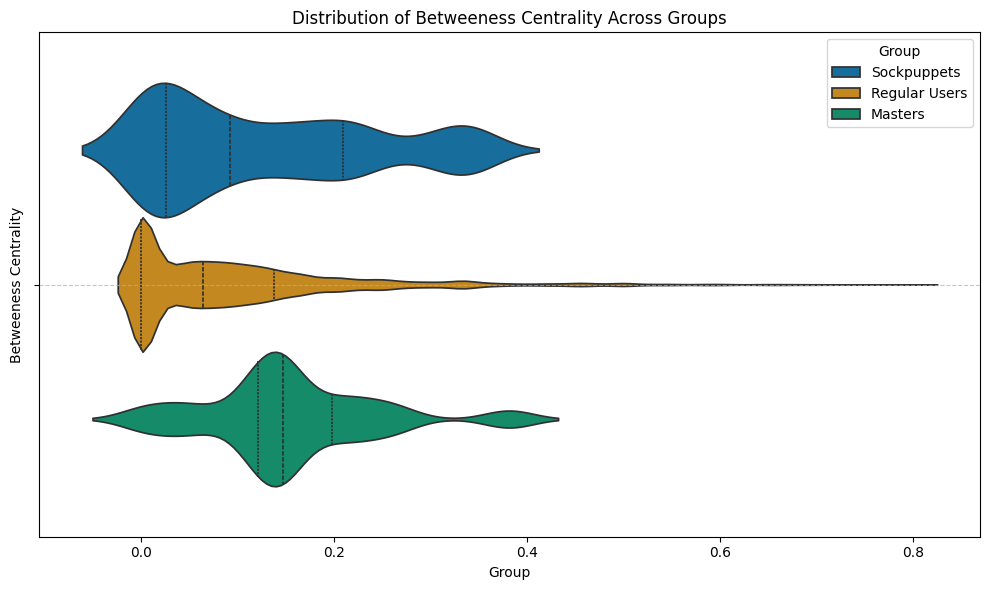

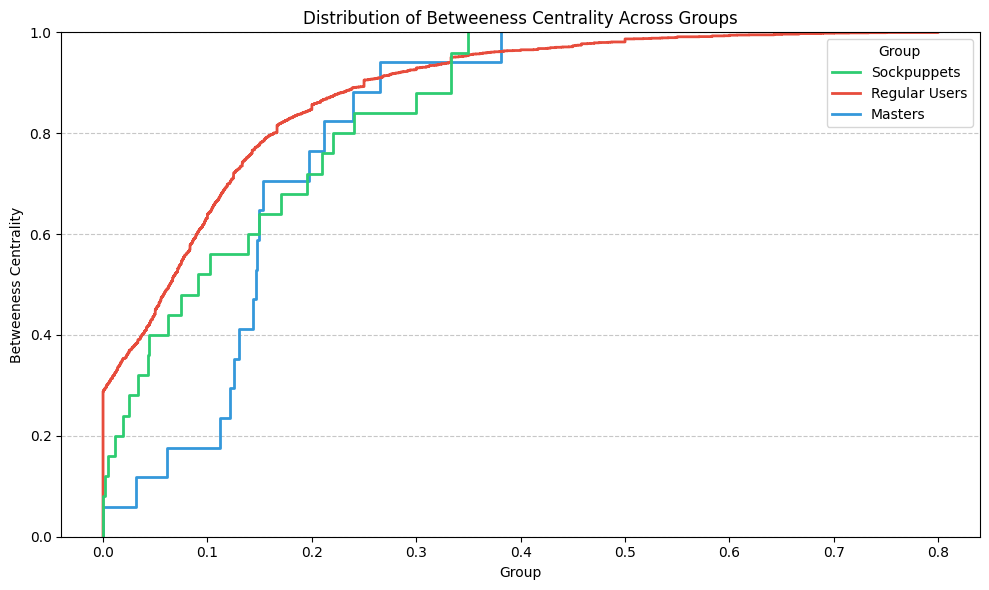

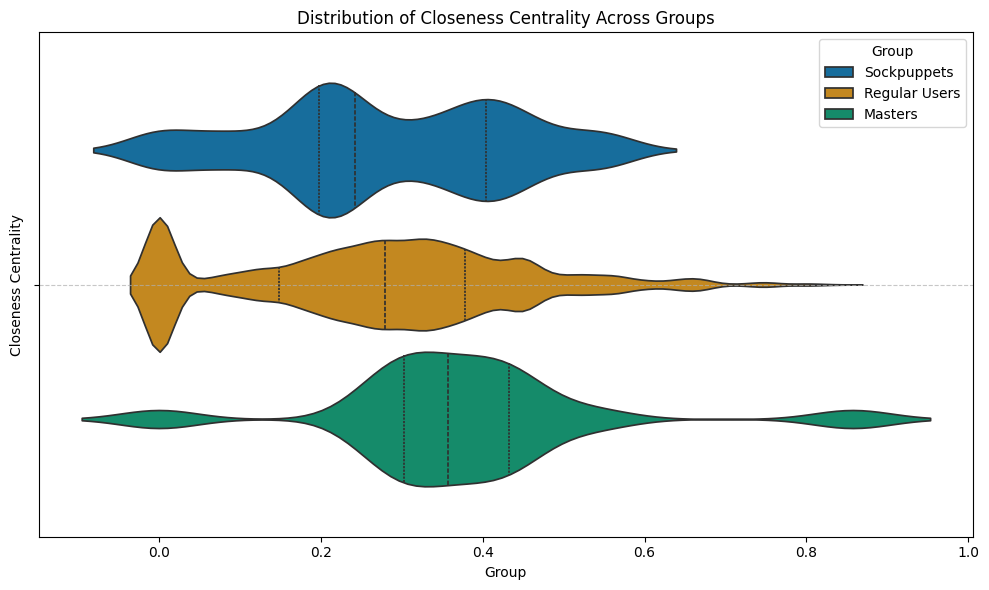

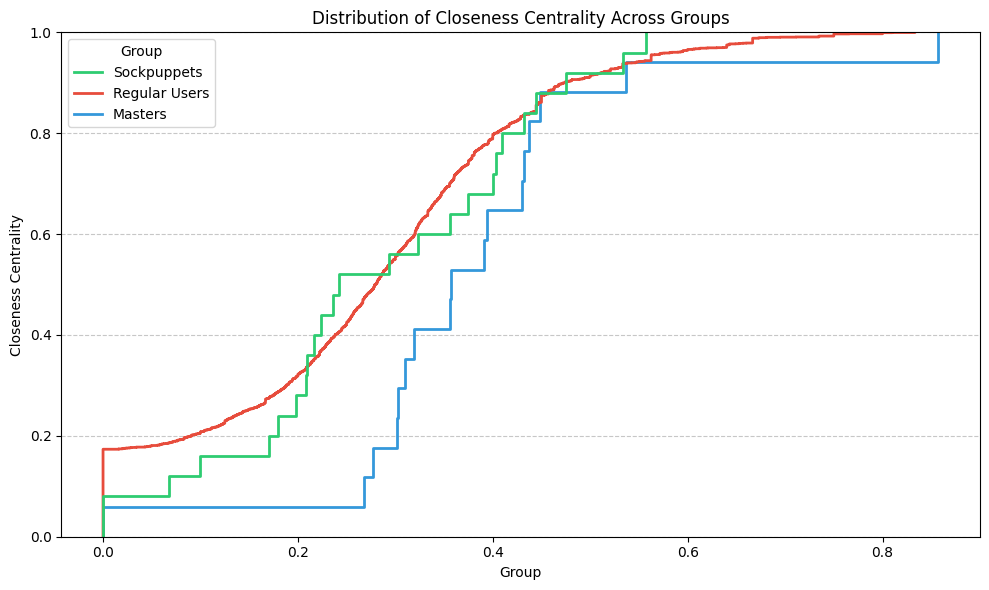

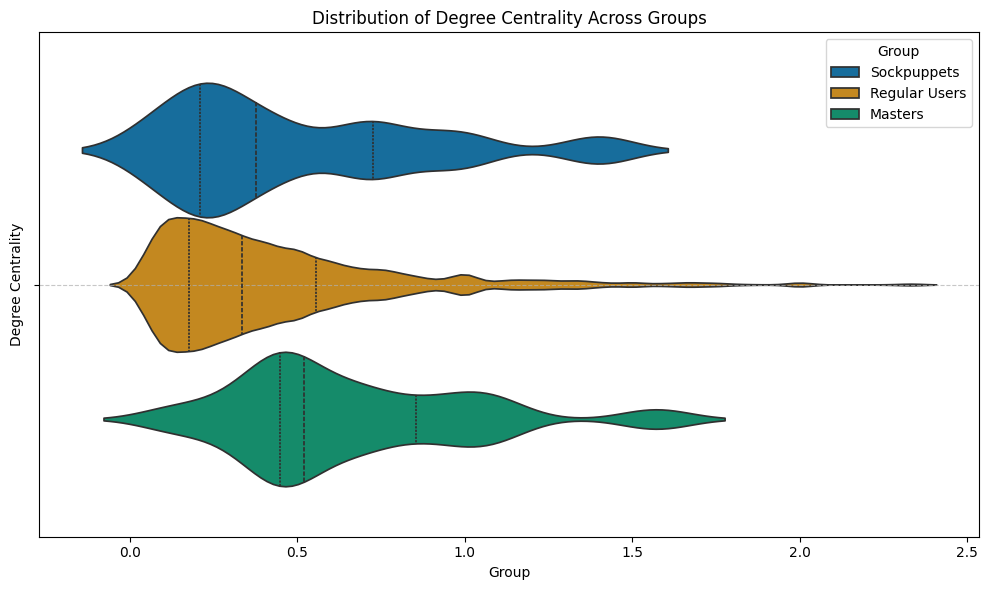

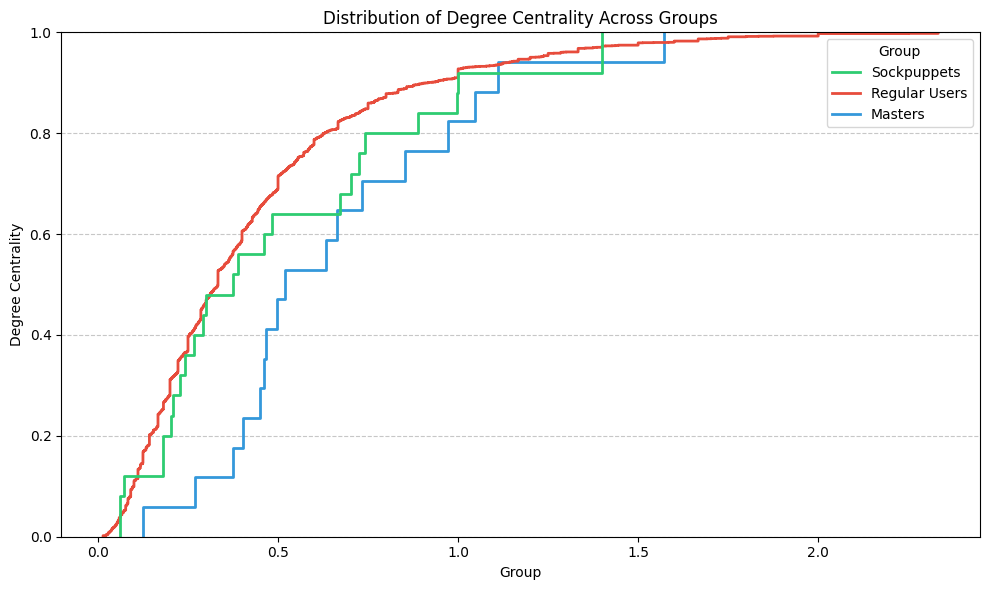

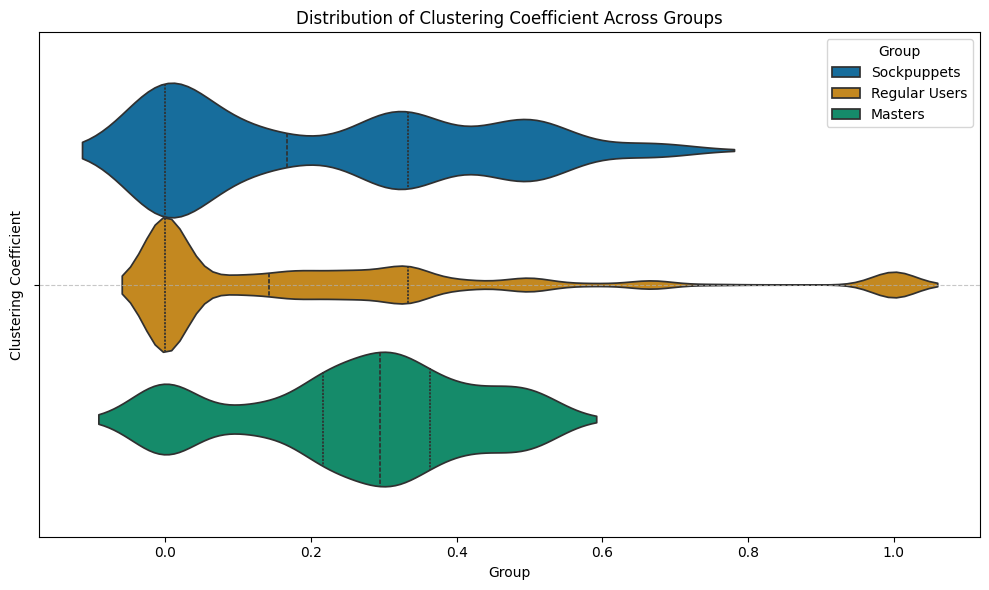

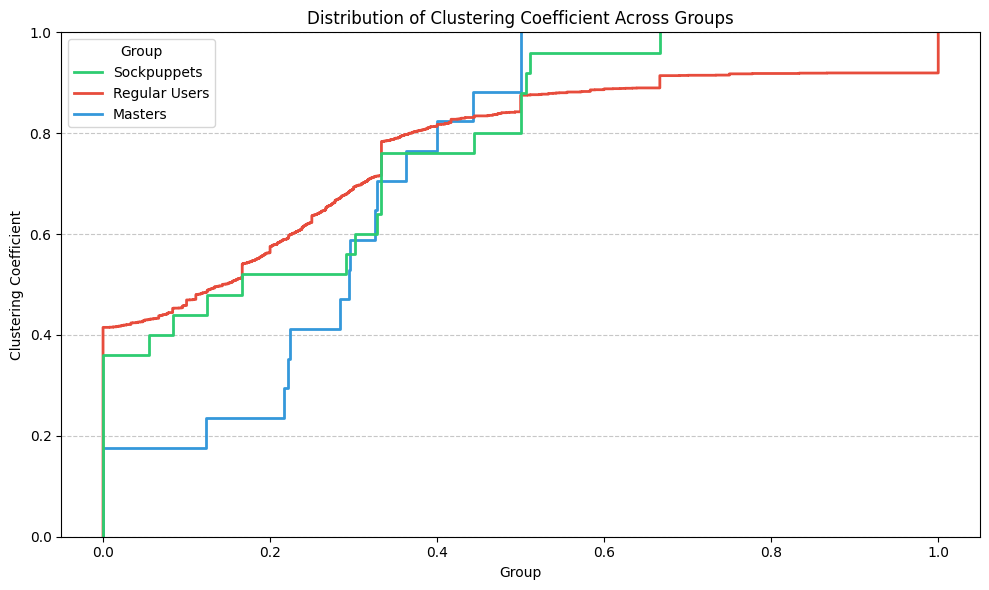

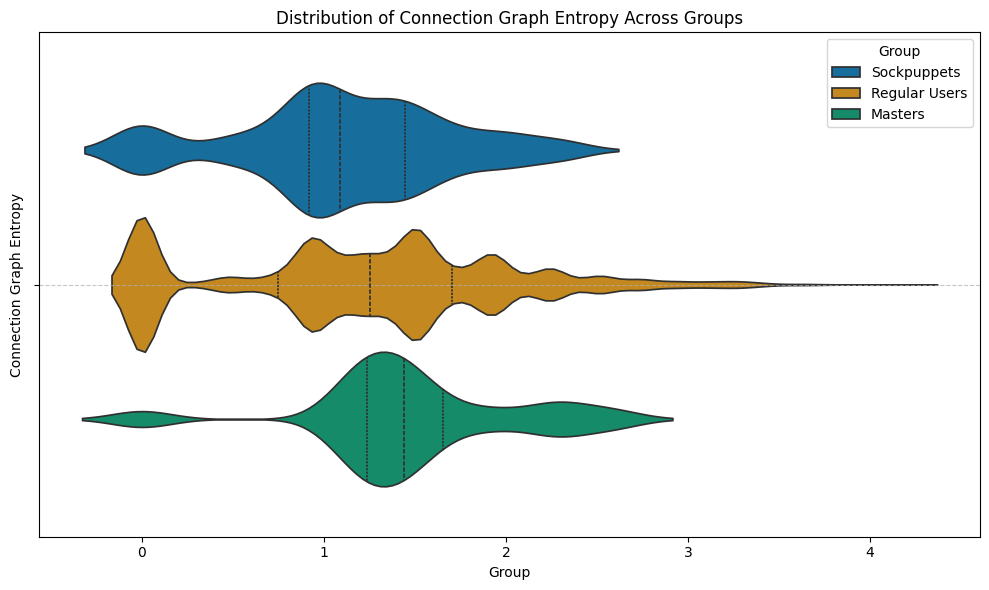

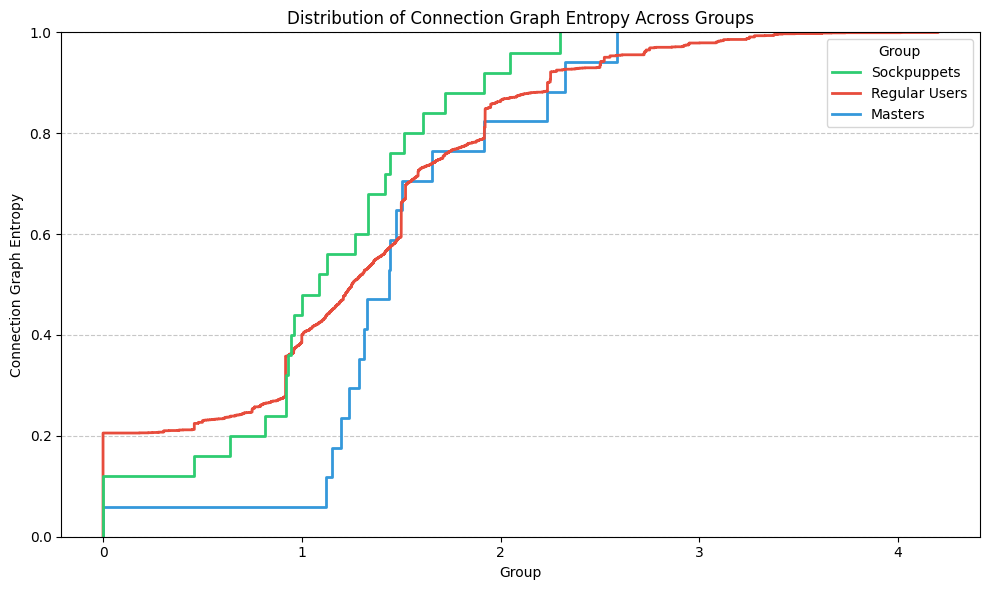

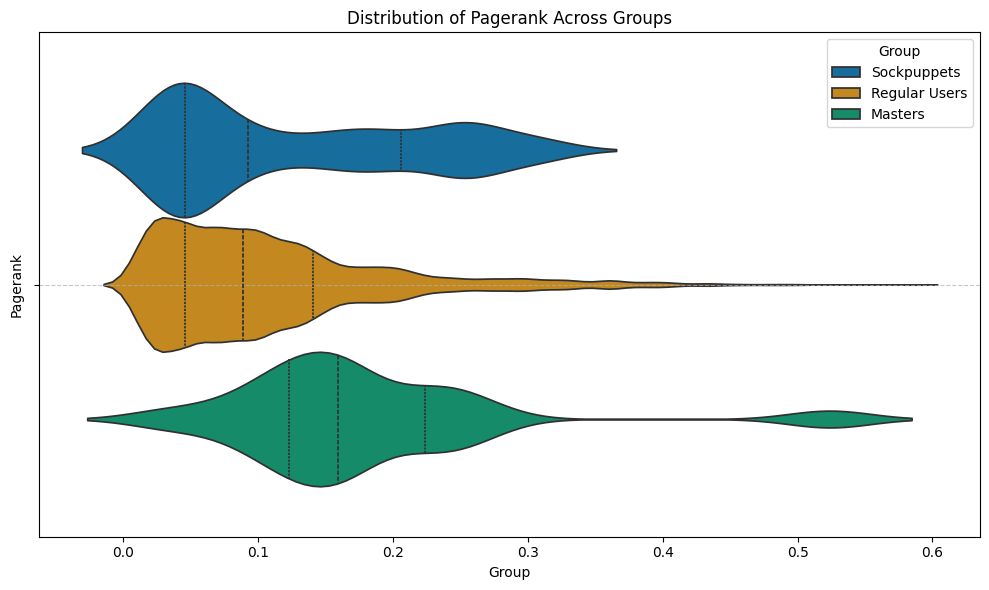

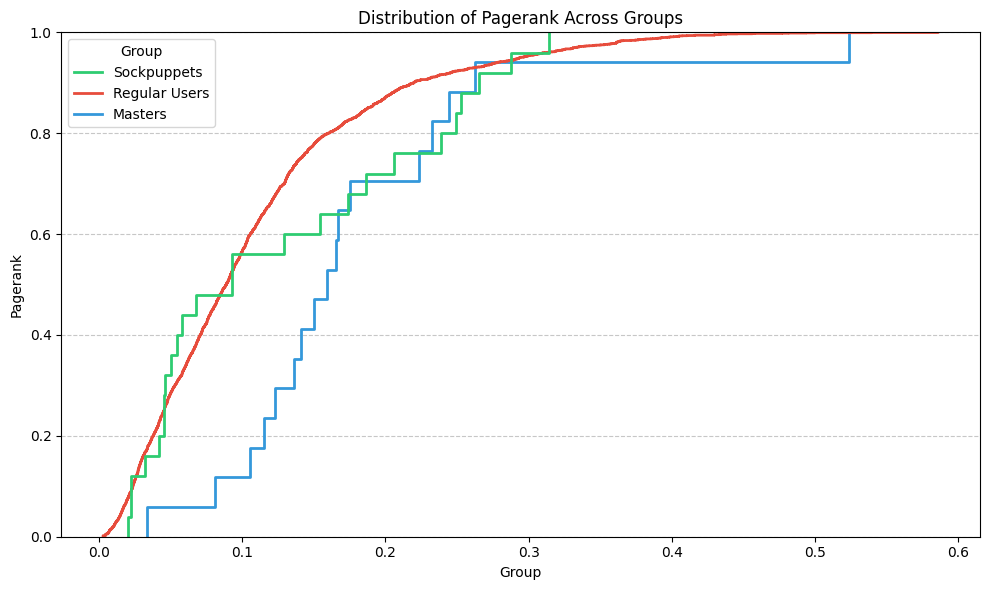

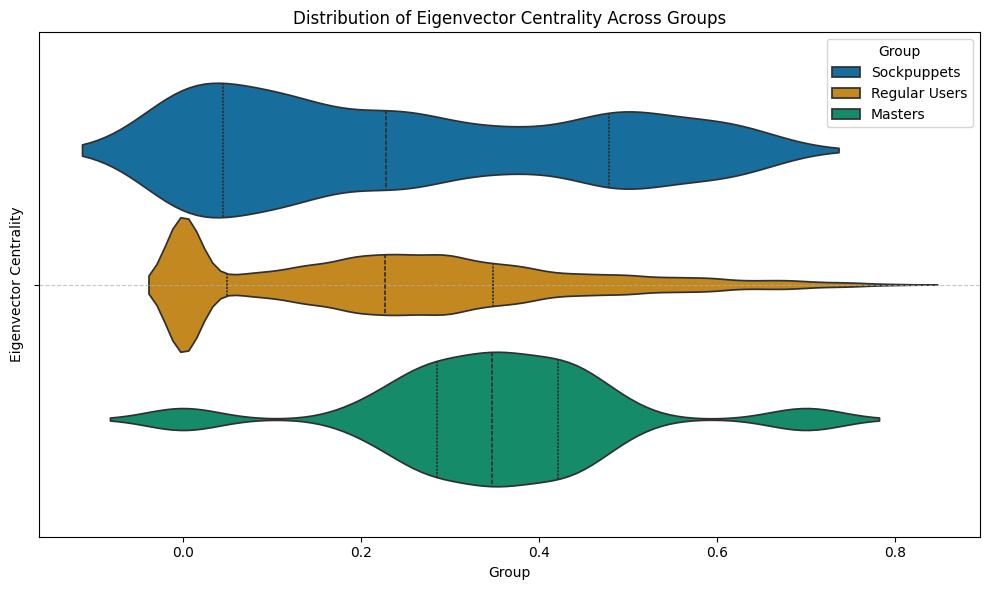

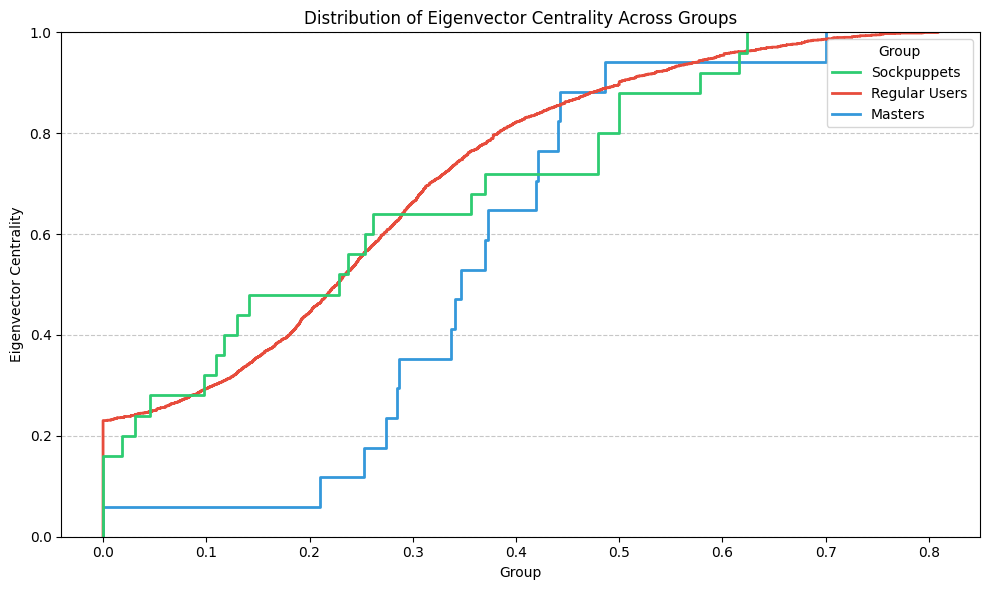

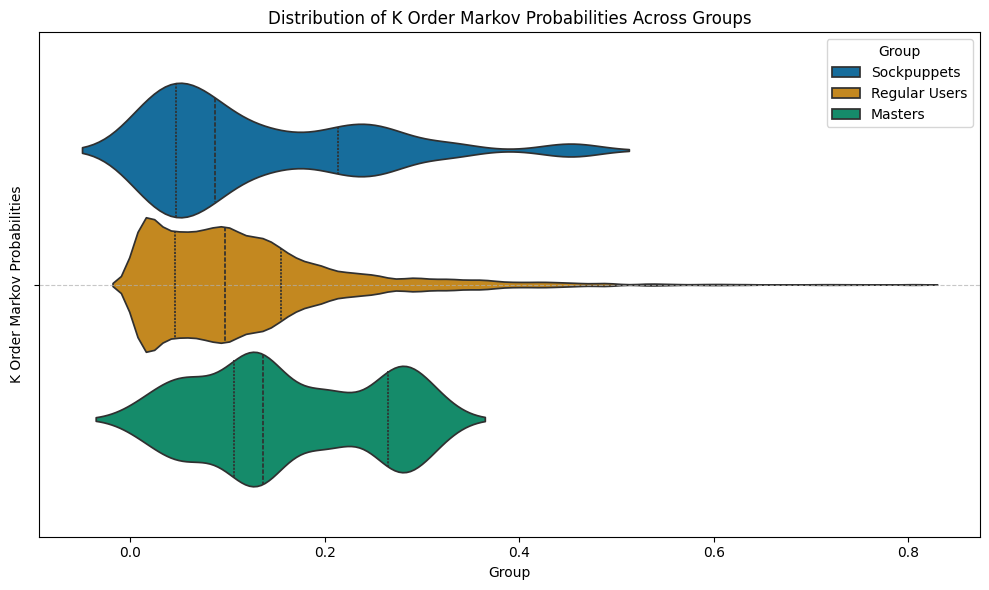

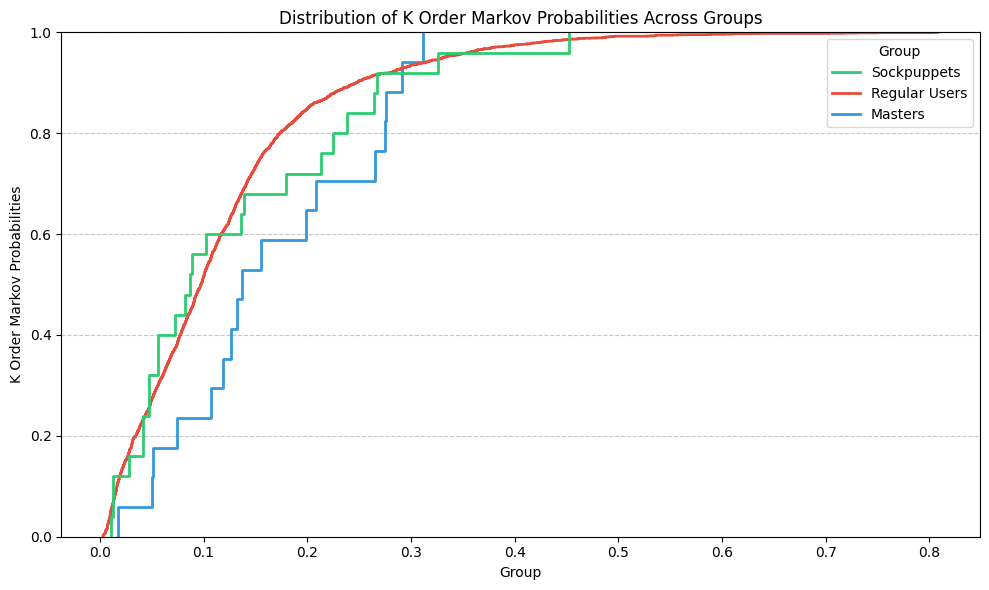

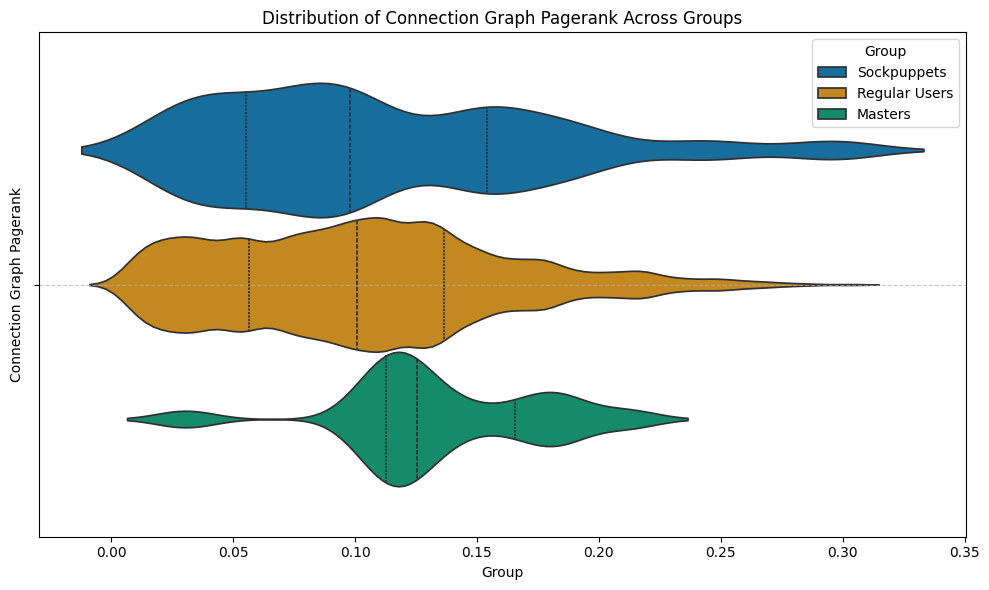

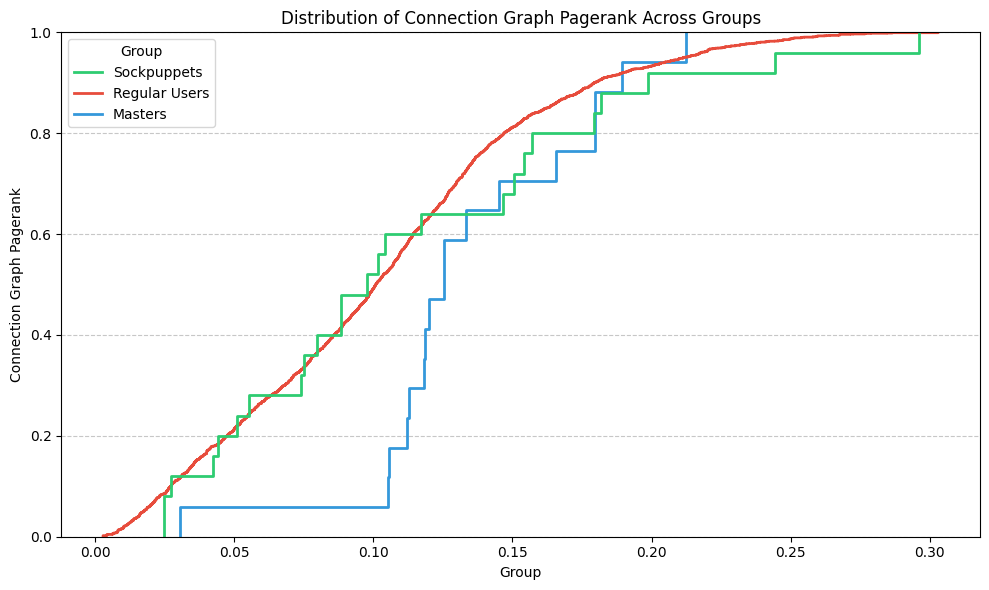

In [ ]:
visualize_distributions_between_groups(sockpuppet_user_metrics, regular_user_metrics, master_user_metrics, a_name="Sockpuppets", b_name="Regular Users", c_name="Masters", groups_are_graphs=False)

In [ ]:
num_of_empty_list_users = 0
num_of_empty_list_puppets = 0
num_of_empty_list_masters = 0
for user in user_dictionary:
  for metric in single_user_metrics:
    user_dictionary[user][metric] = [x for x in user_dictionary[user][metric] if x is not None]
  if len(user_dictionary[user]["pagerank"]) == 0:
    num_of_empty_list_users += 1
    if classify_user(user)[0] == "Puppet":
      num_of_empty_list_puppets += 1
    elif classify_user(user)[0] == "Puppet Master":
      num_of_empty_list_masters += 1

print(f"Number of empty list users: {num_of_empty_list_users}")
print(f"Number of empty list puppets: {num_of_empty_list_puppets}")
print(f"Number of empty list masters: {num_of_empty_list_masters}")

Number of empty list users: 334
Number of empty list puppets: 1
Number of empty list masters: 2
